# Experiment 3.0 — Phase C layer-wise multi-$\tau_{\mathrm{syn}}$ comparison

## Scientific question

Phase B established that a two-layer feed-forward SNN can learn the gesture task and that
timestep_ce and relative_10bin_ce impose different temporal supervision. Experiment 3.0 asks:

> **At fixed network width, does the layer-wise allocation of short and long synaptic time scales affect classification performance, and does that effect depend on the training objective?**

### Fixed network and configurations

\[
\text{Input}
\rightarrow 128
\rightarrow 128
\rightarrow K
\]

Both hidden layers always contain 128 Synaptic-LIF neurons. For multi-shift layers, neurons
are allocated as evenly as possible; remainder neurons are placed at the fastest and slowest
endpoints.

| Configuration | Layer 1 shifts | Layer 2 shifts | Interpretation |
|---|---|---|---|
| Single-scale 2 | (2,) | (2,) | Both layers use the same short time scale |
| Single-scale 3 | (3,) | (3,) | Both layers use the same longer time scale |
| Short → Multi-scale | (2, 3) | (2, 3, 4, 5, 6, 7) | Short first layer, broader/longer second layer |
| Multi-scale → Short | (2, 3, 4, 5, 6, 7) | (2, 3) | Broader/longer first layer, short second layer |

- No recurrence.
- Hidden-layer $\tau_{\mathrm{syn}}$ values are heterogeneous but fixed before training.
- $\tau_{\mathrm{mem}}$, threshold, output-layer dynamics, optimizer, data split, and
  training protocol remain fixed.
- Linear hidden/output layers use bias=False.

### Objectives

Every training seed is run under both objectives:

1. timestep_ce
2. relative_10bin_ce

Three paired training seeds are used with one fixed user-disjoint split for each configuration,
giving:

\[
4\ \text{configurations}\times2\ \text{objectives}\times3\ \text{seeds}
=24\ \text{full trainings}.
\]

The validation split selects the best epoch for each run. The test split is evaluated only after
that checkpoint has been selected.

> The saved outputs below are from an earlier baseline execution and are stale for this 24-run comparison. Re-run the notebook from the top before interpreting any tables or figures.

### Diagnostics

In addition to classification metrics, this notebook records:

- validation balanced accuracy vs. epoch by configuration and objective;
- hidden-layer and output firing rates;
- firing rate for each $\tau_{\mathrm{syn}}$ neuron group;
- spike raster plots for the best validation run in every configuration/objective condition.

In [149]:
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass
import hashlib
import json
import math
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import display

import snntorch as snn
from snntorch import surrogate
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the writingRing repository root")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Repository root: /home/ted/project/writingring-viz
PyTorch: 2.11.0+cu130
CUDA available: True


## 1. Configuration

In [150]:
DATASET_ROOTS = [
    REPO_ROOT / "outputs/action0_wavelets_0e5_1_2_4_8_sr_64",
    REPO_ROOT / "outputs/action1_wavelets_0e5_1_2_4_8_sr_64",
]

INCLUDED_LABELS = (
    "A", "B", "C", "D", "E", "X",
    "G", "H", "I", "J", "K", "L",
)

SPLIT_SEED = 12345
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15

SEEDS = (11, 23, 101)

OBJECTIVES = (
    "timestep_ce",
    "relative_10bin_ce",
)
N_RELATIVE_BINS = 10

HIDDEN_WIDTH = 128


@dataclass(frozen=True)
class LayerwiseTauConfiguration:
    configuration_id: str
    label: str
    layer1_shifts: tuple[int, ...]
    layer1_counts: tuple[int, ...]
    layer2_shifts: tuple[int, ...]
    layer2_counts: tuple[int, ...]


def allocate_neurons(
    shift_count: int,
    width: int,
) -> tuple[int, ...]:
    if shift_count <= 0:
        raise ValueError("shift_count must be positive")

    base, remainder = divmod(width, shift_count)
    counts = [base] * shift_count

    if remainder == 1:
        counts[0] += 1
    elif remainder == 2:
        counts[0] += 1
        counts[-1] += 1
    else:
        for index in range(remainder):
            counts[index] += 1

    return tuple(counts)


def make_configuration(
    configuration_id: str,
    label: str,
    layer1_shifts: tuple[int, ...],
    layer2_shifts: tuple[int, ...],
) -> LayerwiseTauConfiguration:
    layer1_counts = allocate_neurons(len(layer1_shifts), HIDDEN_WIDTH)
    layer2_counts = allocate_neurons(len(layer2_shifts), HIDDEN_WIDTH)
    return LayerwiseTauConfiguration(
        configuration_id=configuration_id,
        label=label,
        layer1_shifts=layer1_shifts,
        layer1_counts=layer1_counts,
        layer2_shifts=layer2_shifts,
        layer2_counts=layer2_counts,
    )


CONFIGURATIONS = (
    make_configuration(
        "single_scale_2",
        "Single-scale 2",
        (2,),
        (2,),
    ),
    make_configuration(
        "single_scale_3",
        "Single-scale 3",
        (3,),
        (3,),
    ),
    make_configuration(
        "short_to_multi_scale",
        "Short → Multi-scale",
        (2, 3),
        (2, 3, 4, 5, 6, 7),
    ),
    make_configuration(
        "multi_scale_to_short",
        "Multi-scale → Short",
        (2, 3, 4, 5, 6, 7),
        (2, 3),
    ),
)

CONFIGURATION_BY_ID = {
    configuration.configuration_id: configuration
    for configuration in CONFIGURATIONS
}
EXPECTED_TRAINING_RUNS = (
    len(CONFIGURATIONS) * len(OBJECTIVES) * len(SEEDS)
)

# Keep Phase-B membrane, threshold and output-layer dynamics fixed.
TAU_MEM_MS = 22.54
TAU_SYN_OUT_MS = 77.47
THRESHOLD = 0.5
SURROGATE_SLOPE = 25.0
RESET_MECHANISM = "subtract"

SPIKE_REGULARIZATION = 0.0
FIRING_ONSET_THRESHOLD = 1e-3
ZERO_INPUT_DIAGNOSTIC_STEPS = 200

BATCH_SIZE = 128
NUM_WORKERS = 0
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.0
GRAD_CLIP_NORM = None

RESUME_EXISTING = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EXPERIMENT_ID = "experiment_3_0_phase_c_layerwise_multitau_comparison"
RESULTS_DIR = REPO_ROOT / "notebooks/artifacts" / EXPERIMENT_ID

print("Experiment:", EXPERIMENT_ID)
print("Objectives:", OBJECTIVES)
print("Seeds:", SEEDS)
print("Fixed split seed:", SPLIT_SEED)
print("Hidden width:", HIDDEN_WIDTH)
for configuration in CONFIGURATIONS:
    print(
        configuration.label,
        "L1=", list(zip(configuration.layer1_shifts, configuration.layer1_counts)),
        "L2=", list(zip(configuration.layer2_shifts, configuration.layer2_counts)),
    )
print("Full trainings:", EXPECTED_TRAINING_RUNS)
print("Epoch budget:", NUM_EPOCHS)
print("Device:", DEVICE)
print("Resume existing:", RESUME_EXISTING)

Experiment: experiment_3_0_phase_c_layerwise_multitau_comparison
Objectives: ('timestep_ce', 'relative_10bin_ce')
Seeds: (11, 23, 101)
Fixed split seed: 12345
Hidden width: 128
Single-scale 2 L1= [(2, 128)] L2= [(2, 128)]
Single-scale 3 L1= [(3, 128)] L2= [(3, 128)]
Short → Multi-scale L1= [(2, 64), (3, 64)] L2= [(2, 22), (3, 21), (4, 21), (5, 21), (6, 21), (7, 22)]
Multi-scale → Short L1= [(2, 22), (3, 21), (4, 21), (5, 21), (6, 21), (7, 22)] L2= [(2, 64), (3, 64)]
Full trainings: 24
Epoch budget: 100
Device: cuda
Resume existing: True


## 2. Reproducibility and shift helpers

In [151]:
def derive_seed(master_seed: int, *parts: object) -> int:
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


def worker_init_fn(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def shift_to_alpha(shift: int) -> float:
    return float(1.0 - 2.0 ** (-int(shift)))


def alpha_to_tau_ms(alpha: float, sampling_rate_hz: float) -> float:
    dt_ms = 1000.0 / float(sampling_rate_hz)
    return float(-dt_ms / math.log(float(alpha)))


def build_alpha_vector(shifts, counts):
    return [
        shift_to_alpha(shift)
        for shift, count in zip(shifts, counts)
        for _ in range(int(count))
    ]


def build_group_slices(shifts, counts):
    groups = []
    start = 0
    for shift, count in zip(shifts, counts):
        stop = start + int(count)
        groups.append((int(shift), start, stop))
        start = stop
    return groups


for configuration in CONFIGURATIONS:
    if sum(configuration.layer1_counts) != HIDDEN_WIDTH:
        raise ValueError(
            f"{configuration.configuration_id}: layer 1 counts must sum to HIDDEN_WIDTH"
        )
    if sum(configuration.layer2_counts) != HIDDEN_WIDTH:
        raise ValueError(
            f"{configuration.configuration_id}: layer 2 counts must sum to HIDDEN_WIDTH"
        )
    if len(configuration.layer1_shifts) != len(configuration.layer1_counts):
        raise ValueError(
            f"{configuration.configuration_id}: layer 1 shifts/counts mismatch"
        )
    if len(configuration.layer2_shifts) != len(configuration.layer2_counts):
        raise ValueError(
            f"{configuration.configuration_id}: layer 2 shifts/counts mismatch"
        )

    assert len(
        build_alpha_vector(
            configuration.layer1_shifts,
            configuration.layer1_counts,
        )
    ) == HIDDEN_WIDTH
    assert len(
        build_alpha_vector(
            configuration.layer2_shifts,
            configuration.layer2_counts,
        )
    ) == HIDDEN_WIDTH

## 3. Load and validate unsigned event data

In [152]:
data = load_acceleration_data(
    DATASET_ROOTS,
    repository_root=REPO_ROOT,
    require_reconstruction=False,
)

sampling_rates = {float(m.sampling_rate_hz) for m in data.producer_metadatas}
if len(sampling_rates) != 1:
    raise ValueError(f"Expected one shared sampling rate, got {sampling_rates}")
SAMPLING_RATE_HZ = sampling_rates.pop()

event_contracts = set()
for metadata in data.producer_metadatas:
    raw = metadata.raw
    event_representation = raw.get("event_representation")
    event_feature_schema = raw.get("event_feature_schema")
    event_channel_count = raw.get("event_channel_count")
    encoder_spec_sha256 = raw.get("spike_encoder_spec_sha256")

    if event_representation != "unsigned":
        raise ValueError(
            "Requires event_representation='unsigned'; "
            f"got {event_representation!r}"
        )
    if not isinstance(event_feature_schema, str) or not event_feature_schema:
        raise ValueError("Missing event_feature_schema")
    if not isinstance(event_channel_count, int) or event_channel_count <= 0:
        raise ValueError("event_channel_count must be positive")
    if event_channel_count != metadata.channel_count - 6:
        raise ValueError(
            "Expected six auxiliary IMU channels after event channels; "
            f"event={event_channel_count}, total={metadata.channel_count}"
        )
    if not isinstance(encoder_spec_sha256, str) or len(encoder_spec_sha256) != 64:
        raise ValueError("Missing spike_encoder_spec_sha256")

    event_contracts.add(
        (
            event_representation,
            event_feature_schema,
            event_channel_count,
            encoder_spec_sha256,
        )
    )

if len(event_contracts) != 1:
    raise ValueError(f"Incompatible event contracts: {event_contracts}")

(
    EVENT_REPRESENTATION,
    EVENT_FEATURE_SCHEMA,
    INPUT_CHANNELS,
    ENCODER_SPEC_SHA256,
) = event_contracts.pop()

if INPUT_CHANNELS != 30:
    raise ValueError(
        f"Experiment 3.0 expects 30 polarity-split event channels, got {INPUT_CHANNELS}"
    )

rows = []
included = None if INCLUDED_LABELS is None else set(map(str, INCLUDED_LABELS))
padded_lengths = set()

for package_index, package in enumerate(data.packages):
    padded_lengths.add(int(package.padded_spike_imu.shape[1]))

    for segment_index, label in enumerate(package.labels.astype(str)):
        label = str(label)
        if included is not None and label not in included:
            continue

        valid_length = int(package.valid_lengths[segment_index])
        if valid_length <= 0:
            raise ValueError("valid_length must be positive")

        event_values = np.asarray(
            package.padded_spike_imu[
                segment_index, :valid_length, :INPUT_CHANNELS
            ]
        )
        if np.any(~np.isfinite(event_values)):
            raise ValueError("Non-finite event values")
        if np.any(event_values < 0.0):
            raise ValueError(
                "Unsigned event contract violated for "
                f"{package.user}/action_{package.action}/{segment_index}"
            )

        rows.append(
            {
                "package_index": package_index,
                "segment_index": segment_index,
                "user": str(package.user),
                "action": str(package.action),
                "label": label,
                "valid_length": valid_length,
                "sample_id": f"{package.user}/action_{package.action}/{segment_index}",
            }
        )

if len(padded_lengths) != 1:
    raise ValueError(f"Expected one padded length, got {padded_lengths}")
PADDED_LENGTH = padded_lengths.pop()

manifest = pd.DataFrame(rows)
if manifest.empty:
    raise ValueError("No samples remain after label filtering")

labels_sorted = sorted(manifest["label"].unique().tolist())
CLASS_TO_IDX = {label: i for i, label in enumerate(labels_sorted)}
IDX_TO_CLASS = {i: label for label, i in CLASS_TO_IDX.items()}
manifest["label_idx"] = manifest["label"].map(CLASS_TO_IDX).astype(int)
NUM_CLASSES = len(CLASS_TO_IDX)

DT_MS = 1000.0 / SAMPLING_RATE_HZ
BETA = float(math.exp(-DT_MS / TAU_MEM_MS))
OUTPUT_ALPHA = float(math.exp(-DT_MS / TAU_SYN_OUT_MS))

tau_rows = []
for configuration in CONFIGURATIONS:
    for layer_name, shifts, counts in (
        ("L1", configuration.layer1_shifts, configuration.layer1_counts),
        ("L2", configuration.layer2_shifts, configuration.layer2_counts),
    ):
        for shift, count in zip(shifts, counts):
            alpha = shift_to_alpha(shift)
            tau_rows.append(
                {
                    "configuration": configuration.label,
                    "layer": layer_name,
                    "shift": shift,
                    "neurons": count,
                    "alpha": alpha,
                    "nominal_tau_syn_ms": alpha_to_tau_ms(alpha, SAMPLING_RATE_HZ),
                }
            )

tau_table = pd.DataFrame(tau_rows)

print(
    f"samples={len(manifest)}, classes={NUM_CLASSES}, "
    f"input_channels={INPUT_CHANNELS}"
)
print(f"sampling_rate={SAMPLING_RATE_HZ} Hz, padded_length={PADDED_LENGTH}")
print(
    f"beta={BETA:.6f}, output_alpha={OUTPUT_ALPHA:.6f}, "
    f"threshold={THRESHOLD}"
)
display(tau_table)

samples=853, classes=12, input_channels=30
sampling_rate=64.0 Hz, padded_length=256
beta=0.499968, output_alpha=0.817347, threshold=0.5


,configuration,layer,shift,neurons,alpha,nominal_tau_syn_ms
0,Single-scale 2,L1,2,128,0.750000,54.313430
1,Single-scale 2,L2,2,128,0.750000,54.313430
2,Single-scale 3,L1,3,128,0.875000,117.013683
3,Single-scale 3,L2,3,128,0.875000,117.013683
4,Short → Multi-scale,L1,2,64,0.750000,54.313430
5,Short → Multi-scale,L1,3,64,0.875000,117.013683
6,Short → Multi-scale,L2,2,22,0.750000,54.313430
7,Short → Multi-scale,L2,3,21,0.875000,117.013683
8,Short → Multi-scale,L2,4,21,0.937500,242.103471
9,Short → Multi-scale,L2,5,21,0.968750,492.146161


## 4. One fixed user-disjoint split

In [153]:
def make_user_split(manifest: pd.DataFrame) -> pd.DataFrame:
    users = sorted(manifest["user"].unique().tolist())
    rng = np.random.default_rng(SPLIT_SEED)
    perm = np.array(users, dtype=object)
    rng.shuffle(perm)

    n = len(perm)
    n_train = max(1, int(np.floor(TRAIN_FRACTION * n)))
    n_val = max(1, int(np.floor(VAL_FRACTION * n)))
    if n_train + n_val >= n:
        n_train, n_val = n - 2, 1

    train_users = set(perm[:n_train].tolist())
    val_users = set(perm[n_train:n_train + n_val].tolist())

    out = manifest.copy()
    out["split"] = out["user"].map(
        lambda u: "train" if u in train_users else (
            "val" if u in val_users else "test"
        )
    )
    return out


FIXED_SPLIT_MANIFEST = make_user_split(manifest)

split_summary = FIXED_SPLIT_MANIFEST.groupby("split").agg(
    users=("user", "nunique"),
    samples=("label", "size"),
    classes_present=("label", "nunique"),
)
display(split_summary)

for split_name, sdf in FIXED_SPLIT_MANIFEST.groupby("split"):
    if sdf["label"].nunique() != NUM_CLASSES:
        print(
            f"WARNING: split={split_name!r} contains "
            f"{sdf['label'].nunique()}/{NUM_CLASSES} classes"
        )

,users,samples,classes_present
split,,,
test,3,146,12
train,14,581,12
val,3,126,12


## 5. Dataset and paired DataLoaders

In [154]:
class EventSNNDataset(Dataset):
    def __init__(self, data, subset_manifest: pd.DataFrame):
        self.data = data
        self.df = subset_manifest.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        package = self.data.packages[int(row.package_index)]
        segment_index = int(row.segment_index)
        valid_length = int(row.valid_length)

        x = np.asarray(
            package.padded_spike_imu[
                segment_index, :, :INPUT_CHANNELS
            ],
            dtype=np.float32,
        ).copy()

        if x.shape != (PADDED_LENGTH, INPUT_CHANNELS):
            raise ValueError(f"Unexpected input shape {x.shape}")
        if np.any(x[:valid_length] < 0.0):
            raise ValueError("Unsigned event contract violated")

        x[valid_length:] = 0.0
        valid_mask = np.arange(PADDED_LENGTH) < valid_length

        return {
            "x": torch.from_numpy(x),
            "label": torch.tensor(int(row.label_idx), dtype=torch.long),
            "valid_mask": torch.from_numpy(valid_mask),
            "valid_length": torch.tensor(valid_length, dtype=torch.long),
            "sample_id": str(row.sample_id),
        }


def make_loader(
    subset_manifest: pd.DataFrame,
    *,
    batch_size: int,
    shuffle: bool,
    seed: int,
):
    dataset = EventSNNDataset(data, subset_manifest)
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        generator=generator,
        worker_init_fn=worker_init_fn if NUM_WORKERS > 0 else None,
        pin_memory=torch.cuda.is_available(),
    )


def make_split_loaders(master_seed: int, include_test: bool = False):
    specs = [
        ("train", "train", True),
        ("train_eval", "train", False),
        ("val", "val", False),
    ]
    if include_test:
        specs.append(("test", "test", False))

    loaders = {}
    for name, split_name, shuffle in specs:
        subset = FIXED_SPLIT_MANIFEST[
            FIXED_SPLIT_MANIFEST.split == split_name
        ]
        loaders[name] = make_loader(
            subset,
            batch_size=BATCH_SIZE,
            shuffle=shuffle,
            # Deliberately objective-independent for paired runs.
            seed=derive_seed(master_seed, name, "loader"),
        )
    return loaders

## 6. Relative 10-bin aggregation

In [155]:
def relative_temporal_bin_counts(
    output_spikes: torch.Tensor,
    valid_lengths: torch.Tensor,
    n_bins: int,
) -> torch.Tensor:
    """Return [B, n_bins, K] output-spike counts over relative gesture progress."""
    _, time_steps, _ = output_spikes.shape

    lengths = valid_lengths.to(
        output_spikes.device, dtype=torch.long
    ).clamp_min(1)

    t = torch.arange(
        time_steps,
        device=output_spikes.device,
    )[None, :]

    valid = t < lengths[:, None]

    bin_index = torch.div(
        t * n_bins,
        lengths[:, None],
        rounding_mode="floor",
    ).clamp_max(n_bins - 1)

    one_hot = F.one_hot(
        bin_index,
        num_classes=n_bins,
    ).to(output_spikes.dtype)

    one_hot = one_hot * valid.unsqueeze(-1).to(output_spikes.dtype)

    return torch.einsum(
        "btn,btk->bnk",
        one_hot,
        output_spikes,
    )

## 7. Two-layer hierarchical multi-$\tau_{\mathrm{syn}}$ SNN

The hidden-layer decay factors follow

\[
\alpha_s = 1-2^{-s}.
\]

At 64 Hz this gives approximately:

| shift | alpha | nominal tau_syn |
|---:|---:|---:|
| 2 | 0.75 | 54 ms |
| 3 | 0.875 | 117 ms |
| 4 | 0.9375 | 242 ms |
| 5 | 0.96875 | 492 ms |
| 6 | 0.984375 | 0.99 s |
| 7 | 0.9921875 | 1.99 s |

The hidden $\alpha$ vectors are assigned neuron-by-neuron and are not learnable.

In [156]:
class PhaseCMultiTauSNN(nn.Module):
    """Two-layer feed-forward heterogeneous multi-tau_syn Synaptic-LIF network."""

    def __init__(
        self,
        *,
        objective: str,
        configuration: LayerwiseTauConfiguration,
        num_classes: int,
        input_channels: int,
        master_seed: int,
    ):
        super().__init__()

        if objective not in OBJECTIVES:
            raise ValueError(f"Unknown objective: {objective}")

        self.objective = str(objective)
        self.configuration = configuration
        self.configuration_id = configuration.configuration_id
        self.width = int(HIDDEN_WIDTH)
        self.depth = 2
        self.num_classes = int(num_classes)
        self.input_channels = int(input_channels)

        self.layer_group_specs = (
            tuple(zip(configuration.layer1_shifts, configuration.layer1_counts)),
            tuple(zip(configuration.layer2_shifts, configuration.layer2_counts)),
        )
        self.layer_group_slices = (
            tuple(build_group_slices(configuration.layer1_shifts, configuration.layer1_counts)),
            tuple(build_group_slices(configuration.layer2_shifts, configuration.layer2_counts)),
        )

        spike_grad = surrogate.fast_sigmoid(slope=SURROGATE_SLOPE)

        # Backbone weights are paired across the two objectives for each seed.
        seed_everything(derive_seed(master_seed, "shared_backbone_init"))

        self.fc1 = nn.Linear(input_channels, HIDDEN_WIDTH, bias=False)
        self.lif1 = snn.Synaptic(
            alpha=build_alpha_vector(
                configuration.layer1_shifts,
                configuration.layer1_counts,
            ),
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        self.fc2 = nn.Linear(HIDDEN_WIDTH, HIDDEN_WIDTH, bias=False)
        self.lif2 = snn.Synaptic(
            alpha=build_alpha_vector(
                configuration.layer2_shifts,
                configuration.layer2_counts,
            ),
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        self.fc_out = nn.Linear(HIDDEN_WIDTH, num_classes, bias=False)
        self.lif_out = snn.Synaptic(
            alpha=OUTPUT_ALPHA,
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        if self.objective == "relative_10bin_ce":
            seed_everything(
                derive_seed(master_seed, self.objective, "head_init")
            )
            self.readout_head = nn.Linear(
                N_RELATIVE_BINS * num_classes,
                num_classes,
                bias=True,
            )
        else:
            self.readout_head = None

    @property
    def backbone_parameter_count(self) -> int:
        modules = [self.fc1, self.fc2, self.fc_out]
        return sum(
            p.numel()
            for module in modules
            for p in module.parameters()
        )

    @property
    def readout_parameter_count(self) -> int:
        if self.readout_head is None:
            return 0
        return sum(p.numel() for p in self.readout_head.parameters())

    @property
    def total_parameter_count(self) -> int:
        return sum(p.numel() for p in self.parameters())

    @property
    def spike_neuron_count(self) -> int:
        return 2 * HIDDEN_WIDTH + self.num_classes

    def forward(self, x, valid_mask):
        self.lif1.reset_mem()
        self.lif2.reset_mem()
        self.lif_out.reset_mem()

        spk1_rec = []
        spk2_rec = []
        out_rec = []

        for step in range(x.shape[1]):
            h1, _, _ = self.lif1(self.fc1(x[:, step, :]))
            h2, _, _ = self.lif2(self.fc2(h1))
            spk_out, _, _ = self.lif_out(self.fc_out(h2))

            spk1_rec.append(h1)
            spk2_rec.append(h2)
            out_rec.append(spk_out)

        hidden_spikes = [
            torch.stack(spk1_rec, dim=1),
            torch.stack(spk2_rec, dim=1),
        ]
        output_spikes = torch.stack(out_rec, dim=1)

        mask_f = valid_mask.unsqueeze(-1).to(output_spikes.dtype)

        total_valid_spikes = (
            sum((spikes * mask_f).sum() for spikes in hidden_spikes)
            + (output_spikes * mask_f).sum()
        )

        return {
            "hidden_spikes": hidden_spikes,
            "output_spikes": output_spikes,
            "total_valid_spikes": total_valid_spikes,
        }

    def native_logits(
        self,
        out,
        valid_lengths,
        valid_mask=None,
    ):
        if self.objective == "timestep_ce":
            if valid_mask is None:
                t = torch.arange(
                    out["output_spikes"].shape[1],
                    device=out["output_spikes"].device,
                )[None, :]
                valid_mask = t < valid_lengths[:, None]

            return (
                out["output_spikes"]
                * valid_mask.unsqueeze(-1).to(out["output_spikes"].dtype)
            ).sum(dim=1)

        bins = relative_temporal_bin_counts(
            out["output_spikes"],
            valid_lengths,
            N_RELATIVE_BINS,
        )
        return self.readout_head(bins.flatten(start_dim=1))

    def training_loss(
        self,
        out,
        labels,
        valid_mask,
        valid_lengths,
    ):
        if self.objective == "timestep_ce":
            batch_size, time_steps, class_count = out["output_spikes"].shape
            targets = labels[:, None].expand(batch_size, time_steps)

            loss_per_step = F.cross_entropy(
                out["output_spikes"].reshape(
                    batch_size * time_steps,
                    class_count,
                ),
                targets.reshape(batch_size * time_steps),
                reduction="none",
            ).reshape(batch_size, time_steps)

            mask_f = valid_mask.to(loss_per_step.dtype)

            loss = (
                (loss_per_step * mask_f).sum()
                / mask_f.sum().clamp_min(1)
            )
        else:
            logits = self.native_logits(out, valid_lengths)
            loss = F.cross_entropy(logits, labels)

        if SPIKE_REGULARIZATION > 0:
            valid_neuron_time = (
                valid_mask.to(out["output_spikes"].dtype).sum().clamp_min(1)
                * self.spike_neuron_count
            )
            loss = (
                loss
                + SPIKE_REGULARIZATION
                * out["total_valid_spikes"]
                / valid_neuron_time
            )

        return loss

## 8. Metrics, per-$\tau$ firing rates, and zero-input diagnostics

In [157]:
def classification_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, y_pred)
        ),
        "macro_f1": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
    }


@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()

    total_loss = 0.0
    sample_count = 0
    valid_steps = 0
    y_true, y_pred = [], []

    hidden_spike_totals = [0.0, 0.0]
    group_spike_totals = {
        (layer_idx, shift): 0.0
        for layer_idx, groups in enumerate(model.layer_group_slices)
        for shift, _, _ in groups
    }

    output_spikes_total = 0.0
    silent_output_samples = 0

    for batch in loader:
        x = batch["x"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)
        mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
        lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

        out = model(x, mask)
        loss = model.training_loss(out, y, mask, lengths)
        logits = model.native_logits(out, lengths, mask)
        pred = logits.argmax(dim=1)

        batch_size = len(y)
        batch_valid_steps = int(mask.sum().item())

        total_loss += float(loss.item()) * batch_size
        sample_count += batch_size
        valid_steps += batch_valid_steps

        y_true.extend(y.cpu().tolist())
        y_pred.extend(pred.cpu().tolist())

        mask_f = mask.unsqueeze(-1).to(out["output_spikes"].dtype)

        for layer_idx, spikes in enumerate(out["hidden_spikes"]):
            hidden_spike_totals[layer_idx] += float(
                (spikes * mask_f).sum().item()
            )

            for shift, start, stop in model.layer_group_slices[layer_idx]:
                group_spike_totals[(layer_idx, shift)] += float(
                    (
                        spikes[:, :, start:stop] * mask_f
                    ).sum().item()
                )

        batch_out = (out["output_spikes"] * mask_f).sum(dim=(1, 2))
        output_spikes_total += float(batch_out.sum().item())
        silent_output_samples += int((batch_out == 0).sum().item())

    metrics = classification_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / max(sample_count, 1)

    total_hidden_spikes = sum(hidden_spike_totals)

    metrics["mean_hidden_firing_rate"] = (
        total_hidden_spikes
        / max(valid_steps * 2 * HIDDEN_WIDTH, 1)
    )

    for layer_idx, total in enumerate(hidden_spike_totals, start=1):
        metrics[f"hidden_{layer_idx}_firing_rate"] = (
            total / max(valid_steps * HIDDEN_WIDTH, 1)
        )

    for layer_idx, groups in enumerate(model.layer_group_slices):
        for shift, start, stop in groups:
            group_size = stop - start
            metrics[
                f"hidden_{layer_idx + 1}_shift_{shift}_firing_rate"
            ] = (
                group_spike_totals[(layer_idx, shift)]
                / max(valid_steps * group_size, 1)
            )

    metrics["output_firing_rate"] = (
        output_spikes_total
        / max(valid_steps * NUM_CLASSES, 1)
    )

    metrics["network_firing_rate"] = (
        (total_hidden_spikes + output_spikes_total)
        / max(valid_steps * model.spike_neuron_count, 1)
    )

    metrics["silent_output_fraction"] = (
        silent_output_samples / max(sample_count, 1)
    )
    metrics["samples"] = sample_count

    return metrics


@torch.no_grad()
def zero_input_activity(
    model,
    steps=ZERO_INPUT_DIAGNOSTIC_STEPS,
):
    model.eval()

    x = torch.zeros(
        1,
        steps,
        INPUT_CHANNELS,
        device=DEVICE,
    )
    mask = torch.ones(
        1,
        steps,
        dtype=torch.bool,
        device=DEVICE,
    )

    out = model(x, mask)

    result = {
        "zero_hidden_1_firing_rate": float(
            out["hidden_spikes"][0].mean().item()
        ),
        "zero_hidden_2_firing_rate": float(
            out["hidden_spikes"][1].mean().item()
        ),
        "zero_output_firing_rate": float(
            out["output_spikes"].mean().item()
        ),
    }

    result["zero_mean_hidden_firing_rate"] = float(
        np.mean(
            [
                result["zero_hidden_1_firing_rate"],
                result["zero_hidden_2_firing_rate"],
            ]
        )
    )
    return result

## 9. Fixed-budget training and best-validation-BA checkpoint

In [158]:
def _cpu_state_dict(model):
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }


def train_one_configuration(
    *,
    configuration: LayerwiseTauConfiguration,
    objective: str,
    master_seed: int,
    train_loader,
    train_eval_loader,
    val_loader,
):
    model = PhaseCMultiTauSNN(
        configuration=configuration,
        objective=objective,
        num_classes=NUM_CLASSES,
        input_channels=INPUT_CHANNELS,
        master_seed=master_seed,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_state = None
    best_val_ba = -np.inf
    best_val_loss = np.inf
    best_epoch = -1
    firing_onset_epoch = None
    history_rows = []

    zero_before = zero_input_activity(model)

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()

        for batch in train_loader:
            x = batch["x"].to(DEVICE, non_blocking=True)
            y = batch["label"].to(DEVICE, non_blocking=True)
            mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
            lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            out = model(x, mask)
            loss = model.training_loss(
                out,
                y,
                mask,
                lengths,
            )

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    "Non-finite loss for "
                    f"objective={objective}, seed={master_seed}"
                )

            loss.backward()

            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRAD_CLIP_NORM,
                )

            optimizer.step()

        train_metrics = evaluate_model(model, train_eval_loader)
        val_metrics = evaluate_model(model, val_loader)

        if (
            firing_onset_epoch is None
            and val_metrics["output_firing_rate"] > FIRING_ONSET_THRESHOLD
        ):
            firing_onset_epoch = epoch

        val_ba = val_metrics["balanced_accuracy"]
        val_loss = val_metrics["loss"]

        improved = (
            val_ba > best_val_ba + 1e-12
            or (
                abs(val_ba - best_val_ba) <= 1e-12
                and val_loss < best_val_loss - 1e-12
            )
        )

        if improved:
            best_val_ba = val_ba
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = _cpu_state_dict(model)

        row = {
            "configuration": configuration.configuration_id,
            "configuration_label": configuration.label,
            "objective": objective,
            "seed": master_seed,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_balanced_accuracy": train_metrics["balanced_accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "train_hidden_1_firing_rate": train_metrics[
                "hidden_1_firing_rate"
            ],
            "train_hidden_2_firing_rate": train_metrics[
                "hidden_2_firing_rate"
            ],
            "train_output_firing_rate": train_metrics[
                "output_firing_rate"
            ],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_hidden_1_firing_rate": val_metrics[
                "hidden_1_firing_rate"
            ],
            "val_hidden_2_firing_rate": val_metrics[
                "hidden_2_firing_rate"
            ],
            "val_output_firing_rate": val_metrics[
                "output_firing_rate"
            ],
            "val_silent_output_fraction": val_metrics[
                "silent_output_fraction"
            ],
        }

        for key, value in val_metrics.items():
            if key.startswith("hidden_") and "_shift_" in key:
                row[f"val_{key}"] = value

        history_rows.append(row)

        if epoch == 1 or epoch % 10 == 0 or epoch == NUM_EPOCHS:
            print(
                f"epoch {epoch:>3d} | "
                f"train loss={train_metrics['loss']:.4f} "
                f"train BA={train_metrics['balanced_accuracy']:.4f} | "
                f"val loss={val_metrics['loss']:.4f} "
                f"val BA={val_metrics['balanced_accuracy']:.4f} | "
                f"L1 FR={val_metrics['hidden_1_firing_rate']:.4f} "
                f"L2 FR={val_metrics['hidden_2_firing_rate']:.4f} "
                f"out FR={val_metrics['output_firing_rate']:.4f}"
            )

    if best_state is None:
        raise RuntimeError("No best checkpoint selected")

    model.load_state_dict(best_state)
    zero_after = zero_input_activity(model)

    return {
        "model": model,
        "history": pd.DataFrame(history_rows),
        "best_epoch": best_epoch,
        "best_val_ba": best_val_ba,
        "best_val_loss": best_val_loss,
        "firing_onset_epoch": firing_onset_epoch,
        "zero_before": zero_before,
        "zero_after": zero_after,
    }

## 10. Persistent checkpoints / resume

In [159]:
def objective_tag(objective: str) -> str:
    if objective == "timestep_ce":
        return "timestep"
    if objective == "relative_10bin_ce":
        return "relative10bin"
    raise ValueError(objective)


def checkpoint_path(
    configuration: LayerwiseTauConfiguration,
    objective: str,
    master_seed: int,
):
    return (
        RESULTS_DIR
        / configuration.configuration_id
        / "checkpoints"
        / (
            f"{objective_tag(objective)}_"
            f"seed_{master_seed}_"
            f"width_{HIDDEN_WIDTH}_best_val_ba.pt"
        )
    )


def history_path(
    configuration: LayerwiseTauConfiguration,
    objective: str,
    master_seed: int,
):
    return (
        RESULTS_DIR
        / configuration.configuration_id
        / "histories"
        / (
            f"{objective_tag(objective)}_"
            f"seed_{master_seed}_"
            f"width_{HIDDEN_WIDTH}_history.csv"
        )
    )


def checkpoint_contract(
    configuration: LayerwiseTauConfiguration,
    objective: str,
    master_seed: int,
):
    return {
        "experiment_id": EXPERIMENT_ID,
        "configuration_id": configuration.configuration_id,
        "objective": objective,
        "seed": int(master_seed),
        "split_seed": int(SPLIT_SEED),
        "num_epochs": int(NUM_EPOCHS),
        "input_channels": int(INPUT_CHANNELS),
        "num_classes": int(NUM_CLASSES),
        "hidden_width": int(HIDDEN_WIDTH),
        "n_relative_bins": int(N_RELATIVE_BINS),
        "layer1_shifts": list(configuration.layer1_shifts),
        "layer1_counts": list(configuration.layer1_counts),
        "layer2_shifts": list(configuration.layer2_shifts),
        "layer2_counts": list(configuration.layer2_counts),
        "tau_mem_ms": float(TAU_MEM_MS),
        "tau_syn_out_ms": float(TAU_SYN_OUT_MS),
        "threshold": float(THRESHOLD),
        "sampling_rate_hz": float(SAMPLING_RATE_HZ),
        "encoder_spec_sha256": ENCODER_SPEC_SHA256,
    }


def save_completed_run(
    configuration: LayerwiseTauConfiguration,
    objective: str,
    master_seed: int,
    run,
):
    checkpoint_path(configuration, objective, master_seed).parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    history_path(configuration, objective, master_seed).parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    payload = checkpoint_contract(
        configuration,
        objective,
        master_seed,
    )
    payload.update(
        {
            "best_epoch": int(run["best_epoch"]),
            "best_val_ba": float(run["best_val_ba"]),
            "best_val_loss": float(run["best_val_loss"]),
            "firing_onset_epoch": run["firing_onset_epoch"],
            "zero_before": run["zero_before"],
            "zero_after": run["zero_after"],
            "state_dict": _cpu_state_dict(run["model"]),
        }
    )

    torch.save(
        payload,
        checkpoint_path(configuration, objective, master_seed),
    )

    run["history"].to_csv(
        history_path(configuration, objective, master_seed),
        index=False,
    )


def load_completed_run(
    configuration: LayerwiseTauConfiguration,
    objective: str,
    master_seed: int,
):
    ckpt = checkpoint_path(configuration, objective, master_seed)
    hist = history_path(configuration, objective, master_seed)

    if not (ckpt.exists() and hist.exists()):
        return None

    payload = torch.load(
        ckpt,
        map_location="cpu",
        weights_only=False,
    )

    required = checkpoint_contract(
        configuration,
        objective,
        master_seed,
    )

    for key, expected in required.items():
        if payload.get(key) != expected:
            raise ValueError(
                f"Checkpoint mismatch for {ckpt}: "
                f"{key}={payload.get(key)!r}, expected {expected!r}. "
                "Delete the stale checkpoint or change RESULTS_DIR."
            )

    model = PhaseCMultiTauSNN(
        configuration=configuration,
        objective=objective,
        num_classes=NUM_CLASSES,
        input_channels=INPUT_CHANNELS,
        master_seed=master_seed,
    ).to(DEVICE)

    model.load_state_dict(payload["state_dict"])

    return {
        "model": model,
        "history": pd.read_csv(hist),
        "best_epoch": int(payload["best_epoch"]),
        "best_val_ba": float(payload["best_val_ba"]),
        "best_val_loss": float(payload["best_val_loss"]),
        "firing_onset_epoch": payload.get("firing_onset_epoch"),
        "zero_before": payload.get("zero_before", {}),
        "zero_after": payload.get("zero_after", {}),
    }

## 11. Objective $\times$ seed sweep

This cell performs all 10 full trainings. The split is fixed by `SPLIT_SEED`. Within each master
seed, the two objectives use the same DataLoader randomization and the same backbone
initialization.

In [160]:
run_rows = []
history_frames = []

for configuration in CONFIGURATIONS:
    print("=" * 100)
    print("CONFIGURATION:", configuration.label)
    print("L1:", list(zip(configuration.layer1_shifts, configuration.layer1_counts)))
    print("L2:", list(zip(configuration.layer2_shifts, configuration.layer2_counts)))
    print("=" * 100)

    for objective in OBJECTIVES:
        print("OBJECTIVE:", objective)

        for master_seed in SEEDS:
            print("-" * 100)
            print("MASTER SEED:", master_seed)

            loaders = make_split_loaders(
                master_seed,
                include_test=True,
            )

            run = (
                load_completed_run(
                    configuration,
                    objective,
                    master_seed,
                )
                if RESUME_EXISTING
                else None
            )

            if run is None:
                run = train_one_configuration(
                    configuration=configuration,
                    objective=objective,
                    master_seed=master_seed,
                    train_loader=loaders["train"],
                    train_eval_loader=loaders["train_eval"],
                    val_loader=loaders["val"],
                )
                save_completed_run(
                    configuration,
                    objective,
                    master_seed,
                    run,
                )
            else:
                print(
                    "Loaded completed checkpoint:",
                    checkpoint_path(
                        configuration,
                        objective,
                        master_seed,
                    ),
                )

            model = run["model"]

            train_metrics = evaluate_model(
                model,
                loaders["train_eval"],
            )
            val_metrics = evaluate_model(
                model,
                loaders["val"],
            )

            # Test is touched only after the best epoch was selected on validation BA.
            test_metrics = evaluate_model(
                model,
                loaders["test"],
            )

            row = {
                "experiment": EXPERIMENT_ID,
                "configuration": configuration.configuration_id,
                "configuration_label": configuration.label,
                "objective": objective,
                "seed": master_seed,
                "best_epoch_by_val_ba": run["best_epoch"],
                "best_val_ba": run["best_val_ba"],
                "val_loss_at_best_val_ba": run["best_val_loss"],
                "firing_onset_epoch": run["firing_onset_epoch"],
                "backbone_parameters": model.backbone_parameter_count,
                "readout_parameters": model.readout_parameter_count,
                "total_parameters": model.total_parameter_count,
            }

            for split_name, metrics in (
                ("train", train_metrics),
                ("val", val_metrics),
                ("test", test_metrics),
            ):
                for key, value in metrics.items():
                    row[f"{split_name}_{key}"] = value

            for key, value in run["zero_before"].items():
                row[f"before_{key}"] = value

            for key, value in run["zero_after"].items():
                row[f"after_{key}"] = value

            run_rows.append(row)

            h = run["history"].copy()
            h["configuration"] = configuration.configuration_id
            h["configuration_label"] = configuration.label
            h["objective"] = objective
            h["seed"] = master_seed
            history_frames.append(h)

            print(
                "BEST:",
                f"epoch={run['best_epoch']}",
                f"val BA={val_metrics['balanced_accuracy']:.4f}",
                f"test BA={test_metrics['balanced_accuracy']:.4f}",
                f"test macro-F1={test_metrics['macro_f1']:.4f}",
            )

            del model
            del run

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

results_df = pd.DataFrame(run_rows)
expected_run_keys = {
    (configuration.configuration_id, objective, master_seed)
    for configuration in CONFIGURATIONS
    for objective in OBJECTIVES
    for master_seed in SEEDS
}
actual_run_keys = set(
    zip(
        results_df["configuration"],
        results_df["objective"],
        results_df["seed"],
    )
)
if actual_run_keys != expected_run_keys:
    raise RuntimeError(
        f"Expected {len(expected_run_keys)} unique training runs, "
        f"found {len(actual_run_keys)}"
    )

histories_df = pd.concat(
    history_frames,
    ignore_index=True,
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(
    RESULTS_DIR / "experiment_3_0_results.csv",
    index=False,
)
histories_df.to_csv(
    RESULTS_DIR / "experiment_3_0_all_histories.csv",
    index=False,
)

display(results_df)

CONFIGURATION: Single-scale 2
L1: [(2, 128)]
L2: [(2, 128)]
OBJECTIVE: timestep_ce
----------------------------------------------------------------------------------------------------
MASTER SEED: 11
epoch   1 | train loss=2.4849 train BA=0.0833 | val loss=2.4849 val BA=0.0833 | L1 FR=0.0000 L2 FR=0.0000 out FR=0.0000
epoch  10 | train loss=2.4828 train BA=0.0974 | val loss=2.4849 val BA=0.0833 | L1 FR=0.0001 L2 FR=0.0000 out FR=0.0000
epoch  20 | train loss=2.4762 train BA=0.1338 | val loss=2.4799 val BA=0.1200 | L1 FR=0.0004 L2 FR=0.0004 out FR=0.0012
epoch  30 | train loss=2.4456 train BA=0.1734 | val loss=2.4587 val BA=0.1329 | L1 FR=0.0015 L2 FR=0.0064 out FR=0.0192
epoch  40 | train loss=2.4163 train BA=0.2370 | val loss=2.4449 val BA=0.1865 | L1 FR=0.0024 L2 FR=0.0134 out FR=0.0434
epoch  50 | train loss=2.3869 train BA=0.2679 | val loss=2.4283 val BA=0.1766 | L1 FR=0.0035 L2 FR=0.0243 out FR=0.0690
epoch  60 | train loss=2.3554 train BA=0.3725 | val loss=2.4100 val BA=0.2002 | 

,experiment,configuration,configuration_label,objective,seed,best_epoch_by_val_ba,best_val_ba,val_loss_at_best_val_ba,firing_onset_epoch,backbone_parameters,...,train_hidden_1_shift_6_firing_rate,train_hidden_1_shift_7_firing_rate,val_hidden_1_shift_4_firing_rate,val_hidden_1_shift_5_firing_rate,val_hidden_1_shift_6_firing_rate,val_hidden_1_shift_7_firing_rate,test_hidden_1_shift_4_firing_rate,test_hidden_1_shift_5_firing_rate,test_hidden_1_shift_6_firing_rate,test_hidden_1_shift_7_firing_rate
0,experiment_3_0_phase_c_layerwise_multitau_comp...,single_scale_2,Single-scale 2,timestep_ce,11,75,0.308532,2.384558,20,21760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,experiment_3_0_phase_c_layerwise_multitau_comp...,single_scale_2,Single-scale 2,timestep_ce,23,94,0.317791,2.381742,17,21760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,experiment_3_0_phase_c_layerwise_multitau_comp...,single_scale_2,Single-scale 2,timestep_ce,101,93,0.340013,2.367066,21,21760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,experiment_3_0_phase_c_layerwise_multitau_comp...,single_scale_2,Single-scale 2,relative_10bin_ce,11,96,0.532413,1.975974,21,21760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,experiment_3_0_phase_c_layerwise_multitau_comp...,single_scale_2,Single-scale 2,relative_10bin_ce,23,68,0.559223,1.649634,19,21760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,experiment_3_0_phase_c_layerwise_multitau_comp...,single_scale_2,Single-scale 2,relative_10bin_ce,101,65,0.505261,1.869567,19,21760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,experiment_3_0_phase_c_layerwise_multitau_comp...,single_scale_3,Single-scale 3,timestep_ce,11,92,0.384031,2.309161,3,21760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,experiment_3_0_phase_c_layerwise_multitau_comp...,single_scale_3,Single-scale 3,timestep_ce,23,89,0.411676,2.321564,5,21760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,experiment_3_0_phase_c_layerwise_multitau_comp...,single_scale_3,Single-scale 3,timestep_ce,101,99,0.361177,2.310540,6,21760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,experiment_3_0_phase_c_layerwise_multitau_comp...,single_scale_3,Single-scale 3,relative_10bin_ce,11,88,0.580267,1.797799,7,21760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 12. Aggregate results across the five paired seeds

In [161]:
summary_df = (
    results_df
    .groupby(
        [
            "configuration",
            "configuration_label",
            "objective",
        ],
        sort=False,
    )
    .agg(
        seeds=("seed", "nunique"),
        mean_best_val_ba=("best_val_ba", "mean"),
        sd_best_val_ba=("best_val_ba", "std"),
        mean_test_ba=("test_balanced_accuracy", "mean"),
        sd_test_ba=("test_balanced_accuracy", "std"),
        mean_test_macro_f1=("test_macro_f1", "mean"),
        sd_test_macro_f1=("test_macro_f1", "std"),
        mean_test_output_fr=("test_output_firing_rate", "mean"),
        mean_test_l1_fr=("test_hidden_1_firing_rate", "mean"),
        mean_test_l2_fr=("test_hidden_2_firing_rate", "mean"),
    )
    .reset_index()
)

display(summary_df)

summary_df.to_csv(
    RESULTS_DIR / "experiment_3_0_configuration_objective_summary.csv",
    index=False,
)

def configuration_metadata(configuration: LayerwiseTauConfiguration):
    return {
        "configuration_id": configuration.configuration_id,
        "label": configuration.label,
        "layer_1": {
            "neurons": int(HIDDEN_WIDTH),
            "shift_syn": list(configuration.layer1_shifts),
            "neurons_per_tau_group": list(configuration.layer1_counts),
            "tau_syn_ms": [
                alpha_to_tau_ms(
                    shift_to_alpha(shift),
                    SAMPLING_RATE_HZ,
                )
                for shift in configuration.layer1_shifts
            ],
        },
        "layer_2": {
            "neurons": int(HIDDEN_WIDTH),
            "shift_syn": list(configuration.layer2_shifts),
            "neurons_per_tau_group": list(configuration.layer2_counts),
            "tau_syn_ms": [
                alpha_to_tau_ms(
                    shift_to_alpha(shift),
                    SAMPLING_RATE_HZ,
                )
                for shift in configuration.layer2_shifts
            ],
        },
    }

provenance = {
    "experiment_id": EXPERIMENT_ID,
    "split_seed": SPLIT_SEED,
    "seeds": list(SEEDS),
    "objectives": list(OBJECTIVES),
    "configurations": [
        configuration_metadata(configuration)
        for configuration in CONFIGURATIONS
    ],
    "expected_training_runs": int(EXPECTED_TRAINING_RUNS),
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "hidden_width": HIDDEN_WIDTH,
    "tau_mem_ms": TAU_MEM_MS,
    "tau_syn_out_ms": TAU_SYN_OUT_MS,
    "threshold": THRESHOLD,
    "sampling_rate_hz": SAMPLING_RATE_HZ,
    "input_channels": INPUT_CHANNELS,
    "num_classes": NUM_CLASSES,
    "event_representation": EVENT_REPRESENTATION,
    "event_feature_schema": EVENT_FEATURE_SCHEMA,
    "encoder_spec_sha256": ENCODER_SPEC_SHA256,
}

with open(
    RESULTS_DIR / "experiment_3_0_provenance.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        provenance,
        f,
        indent=2,
        sort_keys=True,
    )

,configuration,configuration_label,objective,seeds,mean_best_val_ba,sd_best_val_ba,mean_test_ba,sd_test_ba,mean_test_macro_f1,sd_test_macro_f1,mean_test_output_fr,mean_test_l1_fr,mean_test_l2_fr
0,single_scale_2,Single-scale 2,timestep_ce,3,0.322112,0.016179,0.317818,0.021805,0.242581,0.037278,0.138252,0.011207,0.093744
1,single_scale_2,Single-scale 2,relative_10bin_ce,3,0.532299,0.026981,0.485279,0.081390,0.470622,0.075458,0.145341,0.005782,0.039460
2,single_scale_3,Single-scale 3,timestep_ce,3,0.385628,0.025287,0.423344,0.027352,0.375665,0.031950,0.128267,0.024816,0.183057
3,single_scale_3,Single-scale 3,relative_10bin_ce,3,0.566741,0.012808,0.559102,0.043772,0.558619,0.040833,0.266616,0.014350,0.102215
4,short_to_multi_scale,Short → Multi-scale,timestep_ce,3,0.322858,0.037565,0.391267,0.054201,0.341530,0.055919,0.096465,0.008712,0.120335
5,short_to_multi_scale,Short → Multi-scale,relative_10bin_ce,3,0.526122,0.018806,0.489475,0.040597,0.487803,0.041510,0.241709,0.006554,0.080382
6,multi_scale_to_short,Multi-scale → Short,timestep_ce,3,0.355008,0.010147,0.327012,0.022832,0.289449,0.029191,0.092155,0.047844,0.129679
7,multi_scale_to_short,Multi-scale → Short,relative_10bin_ce,3,0.499786,0.060383,0.495048,0.079448,0.500863,0.077840,0.186748,0.041004,0.121090


## 13. Validation balanced accuracy vs. epoch

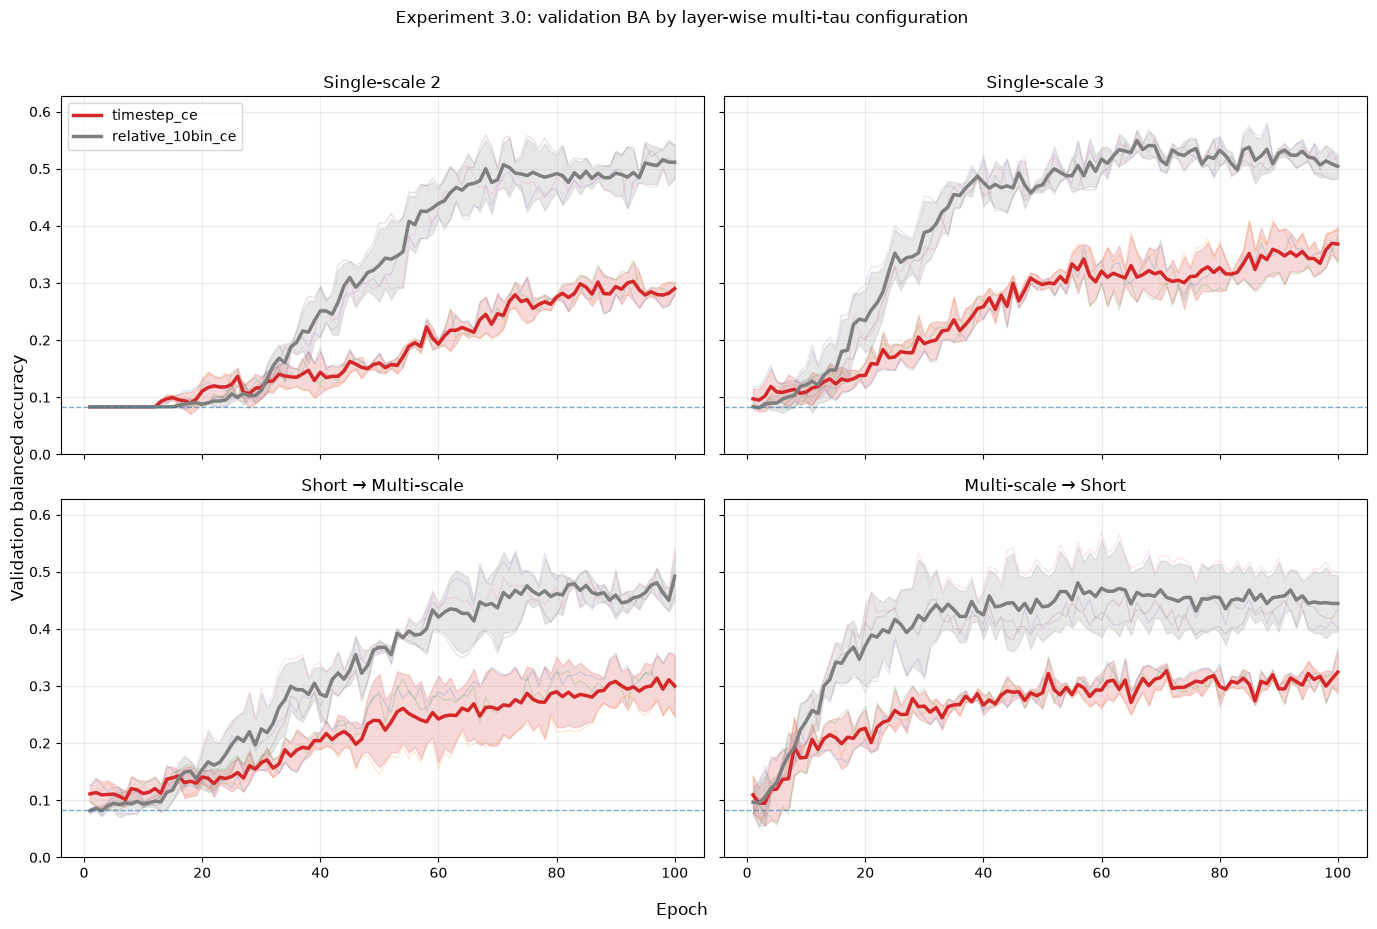

In [162]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    sharex=True,
    sharey=True,
)

for ax, configuration in zip(axes.flat, CONFIGURATIONS):
    configuration_hist = histories_df[
        histories_df.configuration == configuration.configuration_id
    ]

    for objective in OBJECTIVES:
        objective_hist = configuration_hist[
            configuration_hist.objective == objective
        ]

        # Individual seed trajectories.
        for seed in SEEDS:
            seed_hist = objective_hist[
                objective_hist.seed == seed
            ].sort_values("epoch")

            ax.plot(
                seed_hist["epoch"],
                seed_hist["val_balanced_accuracy"],
                alpha=0.18,
                linewidth=1.0,
            )

        # Mean +/- one SD across the three paired seeds.
        epoch_summary = (
            objective_hist
            .groupby("epoch")["val_balanced_accuracy"]
            .agg(["mean", "std"])
            .reset_index()
        )

        mean_line, = ax.plot(
            epoch_summary["epoch"],
            epoch_summary["mean"],
            linewidth=2.5,
            label=objective,
        )

        ax.fill_between(
            epoch_summary["epoch"],
            (
                epoch_summary["mean"] - epoch_summary["std"]
            ).clip(lower=0.0),
            (
                epoch_summary["mean"] + epoch_summary["std"]
            ).clip(upper=1.0),
            alpha=0.18,
            color=mean_line.get_color(),
        )

    ax.axhline(
        1.0 / NUM_CLASSES,
        linestyle="--",
        linewidth=1.0,
        alpha=0.6,
    )
    ax.set_title(configuration.label)
    ax.grid(alpha=0.25)

fig.supxlabel("Epoch")
fig.supylabel("Validation balanced accuracy")
fig.suptitle(
    "Experiment 3.0: validation BA by layer-wise multi-tau configuration",
    y=1.02,
)
axes[0, 0].legend()
axes[0, 0].set_ylim(
    0.0,
    max(
        0.55,
        histories_df["val_balanced_accuracy"].max() * 1.08,
    ),
)

plt.tight_layout()
plt.show()

## 14. Validation/test objective comparison

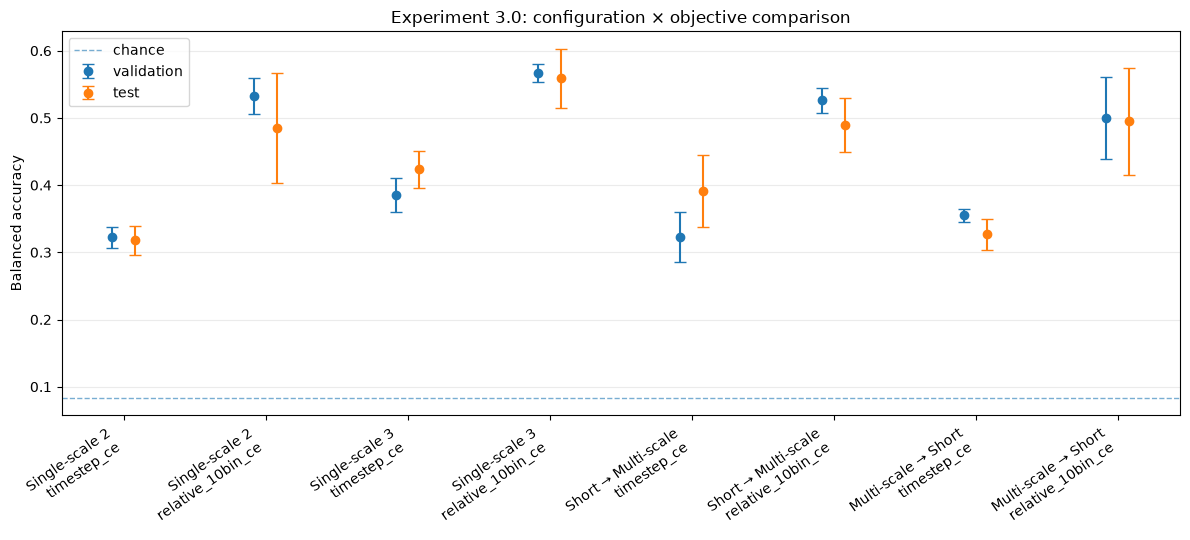

In [163]:
plot_df = summary_df.copy()
plot_df["condition"] = (
    plot_df["configuration_label"]
    + "\n"
    + plot_df["objective"]
)

x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.errorbar(
    x - 0.08,
    plot_df["mean_best_val_ba"],
    yerr=plot_df["sd_best_val_ba"],
    marker="o",
    capsize=4,
    linestyle="none",
    label="validation",
)

ax.errorbar(
    x + 0.08,
    plot_df["mean_test_ba"],
    yerr=plot_df["sd_test_ba"],
    marker="o",
    capsize=4,
    linestyle="none",
    label="test",
)

ax.axhline(
    1.0 / NUM_CLASSES,
    linestyle="--",
    linewidth=1.0,
    alpha=0.6,
    label="chance",
)

ax.set_xticks(
    x,
    plot_df["condition"],
    rotation=35,
    ha="right",
)
ax.set_ylabel("Balanced accuracy")
ax.set_title("Experiment 3.0: configuration × objective comparison")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

## 15. Spike raster visualization

For each objective this section selects the seed with the highest validation BA within that
objective, loads its best checkpoint, then visualizes one deterministic validation gesture.

- x-axis: timestep;
- y-axis: individual neuron index;
- each mark: that neuron fired at that timestep;
- horizontal boundaries: changes in hidden-layer `shift_syn` group.

Single-scale 2 | timestep_ce: raster uses seed=101, best val BA=0.3400


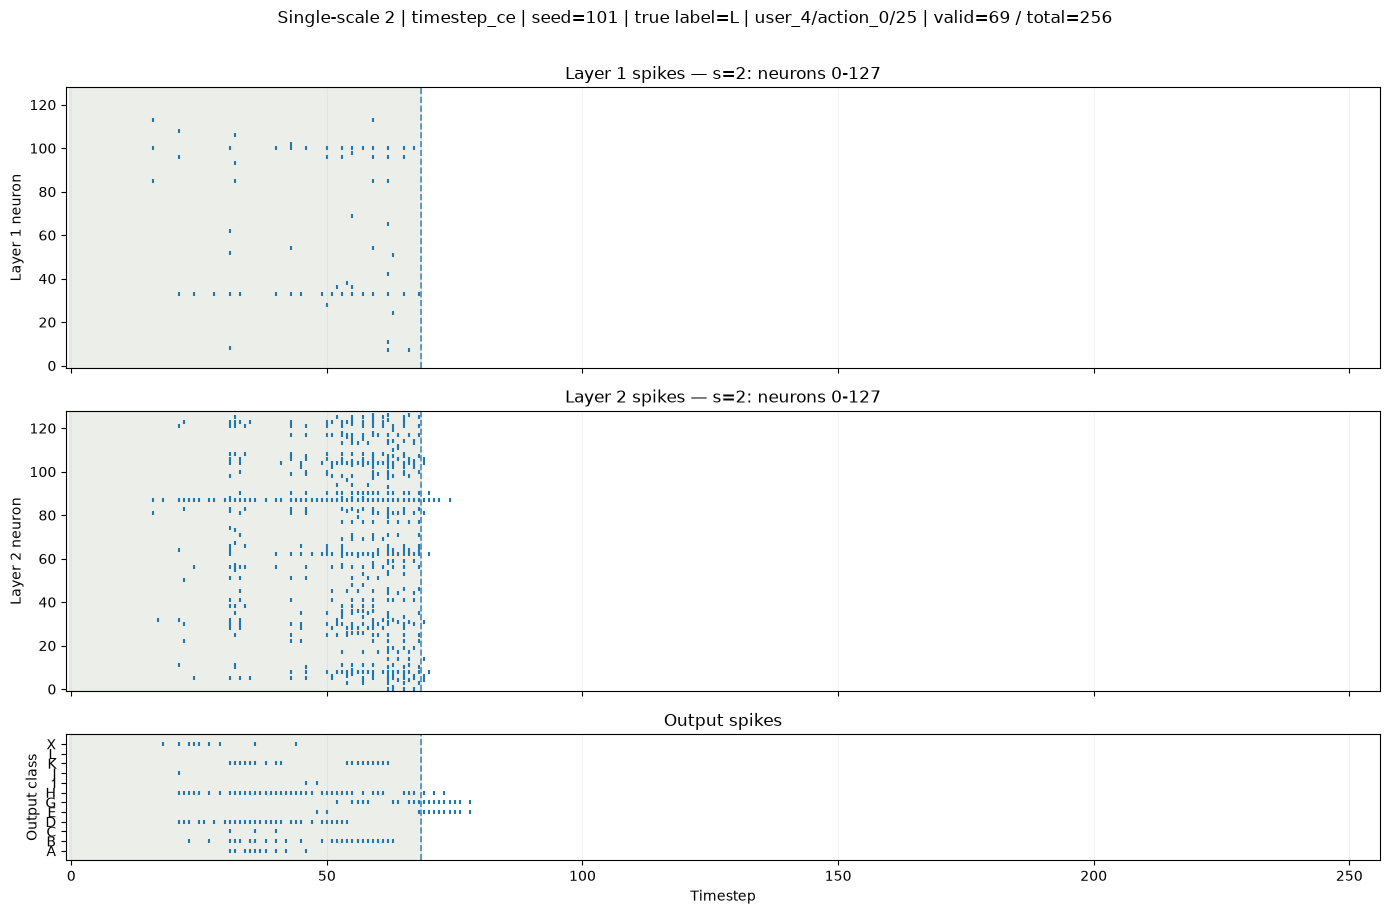

Single-scale 2 | relative_10bin_ce: raster uses seed=23, best val BA=0.5592


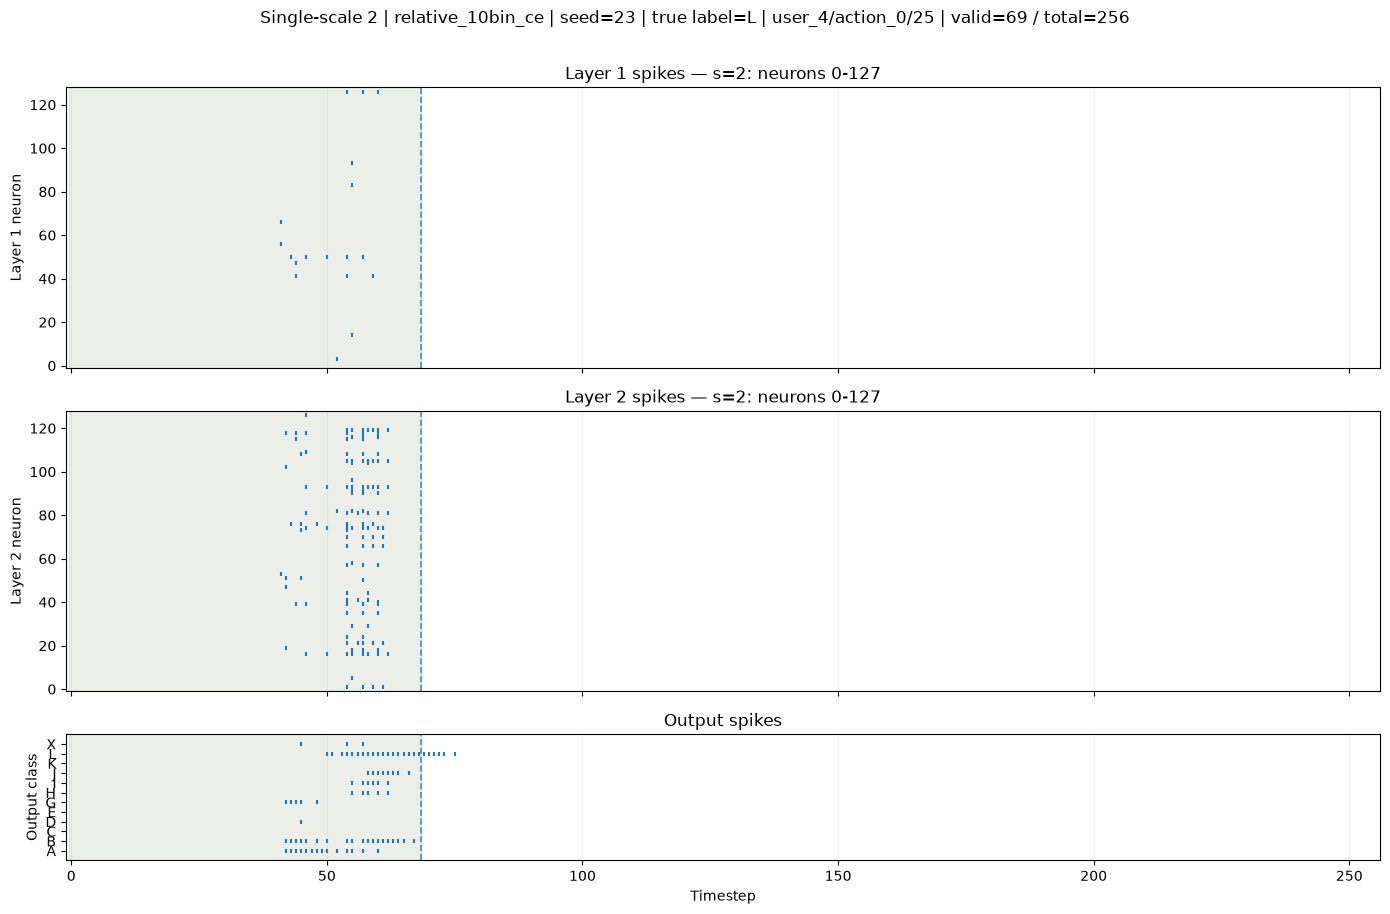

Single-scale 3 | timestep_ce: raster uses seed=23, best val BA=0.4117


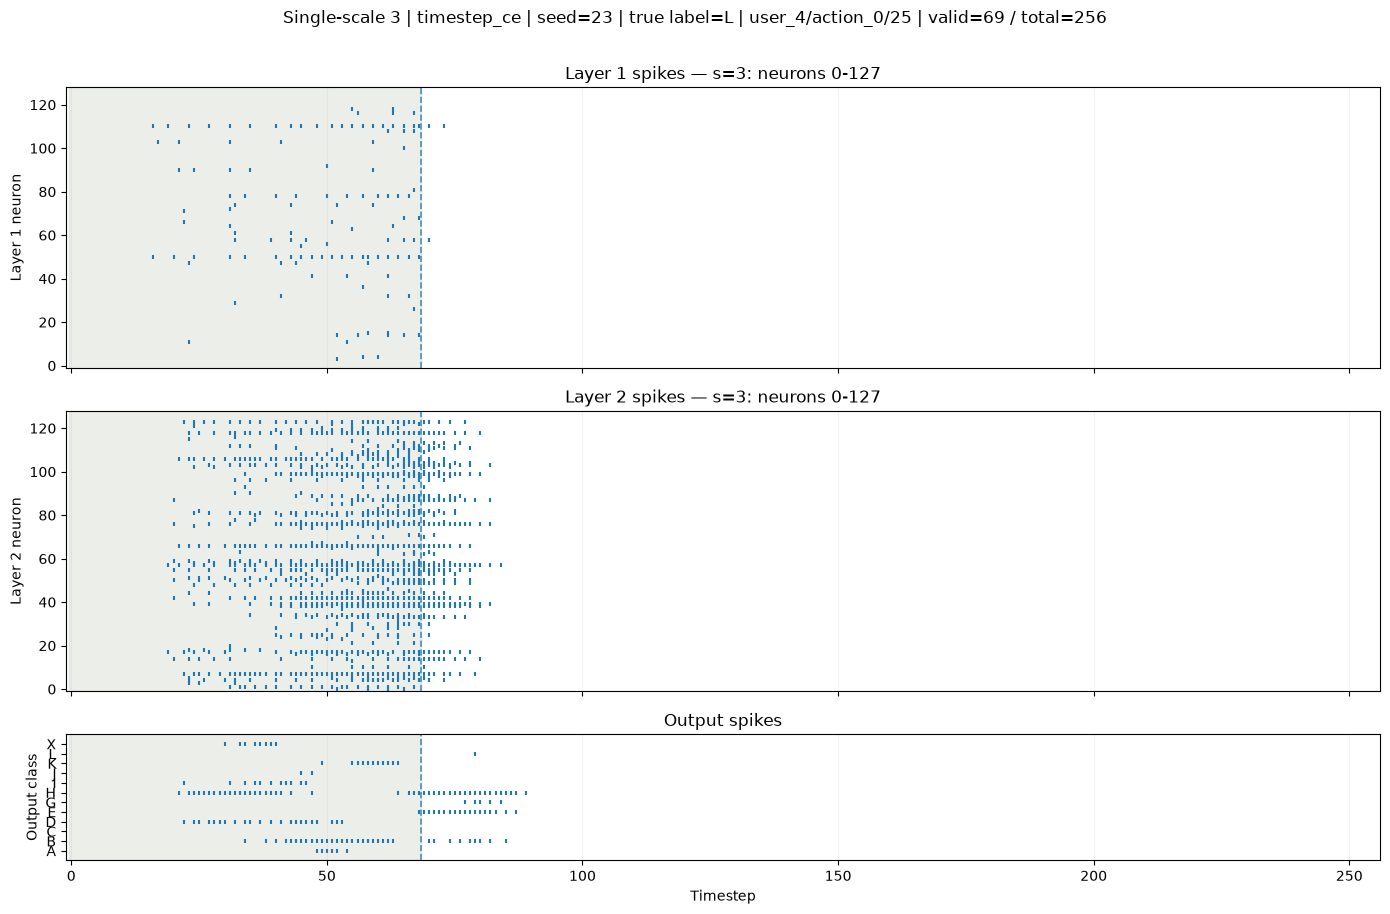

Single-scale 3 | relative_10bin_ce: raster uses seed=11, best val BA=0.5803


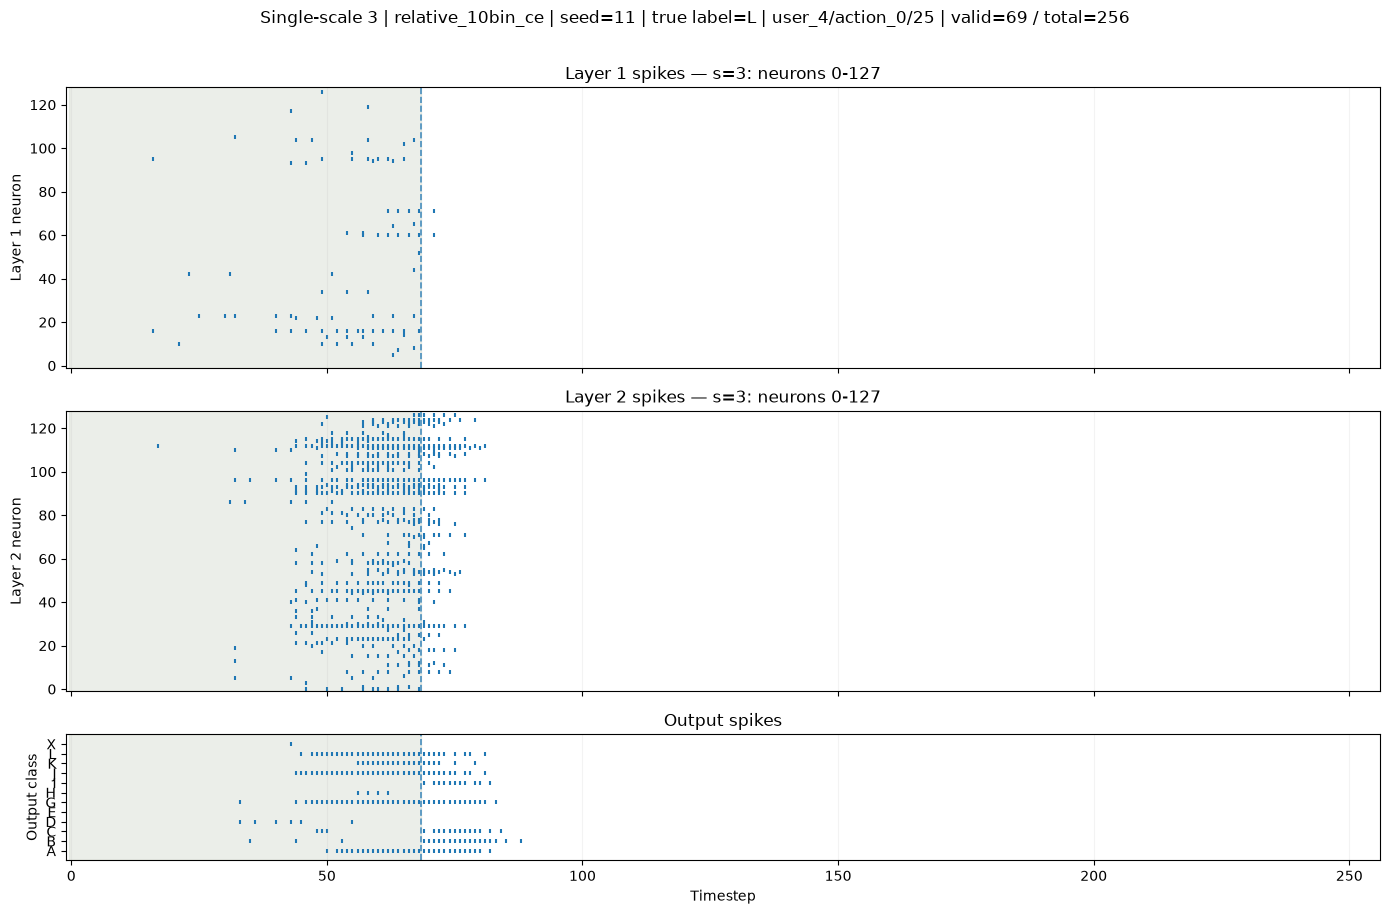

Short → Multi-scale | timestep_ce: raster uses seed=11, best val BA=0.3581


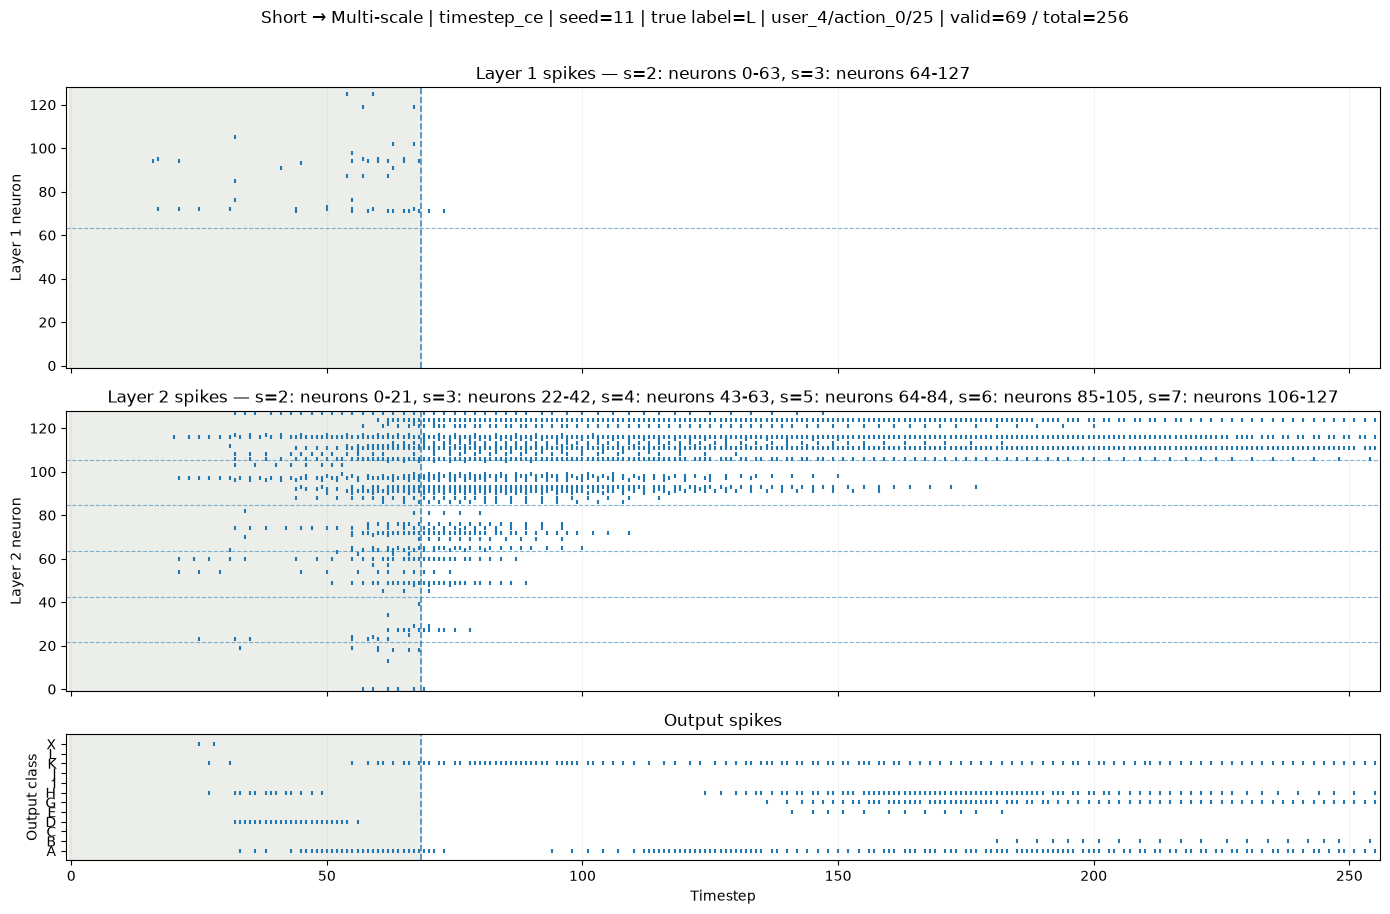

Short → Multi-scale | relative_10bin_ce: raster uses seed=101, best val BA=0.5408


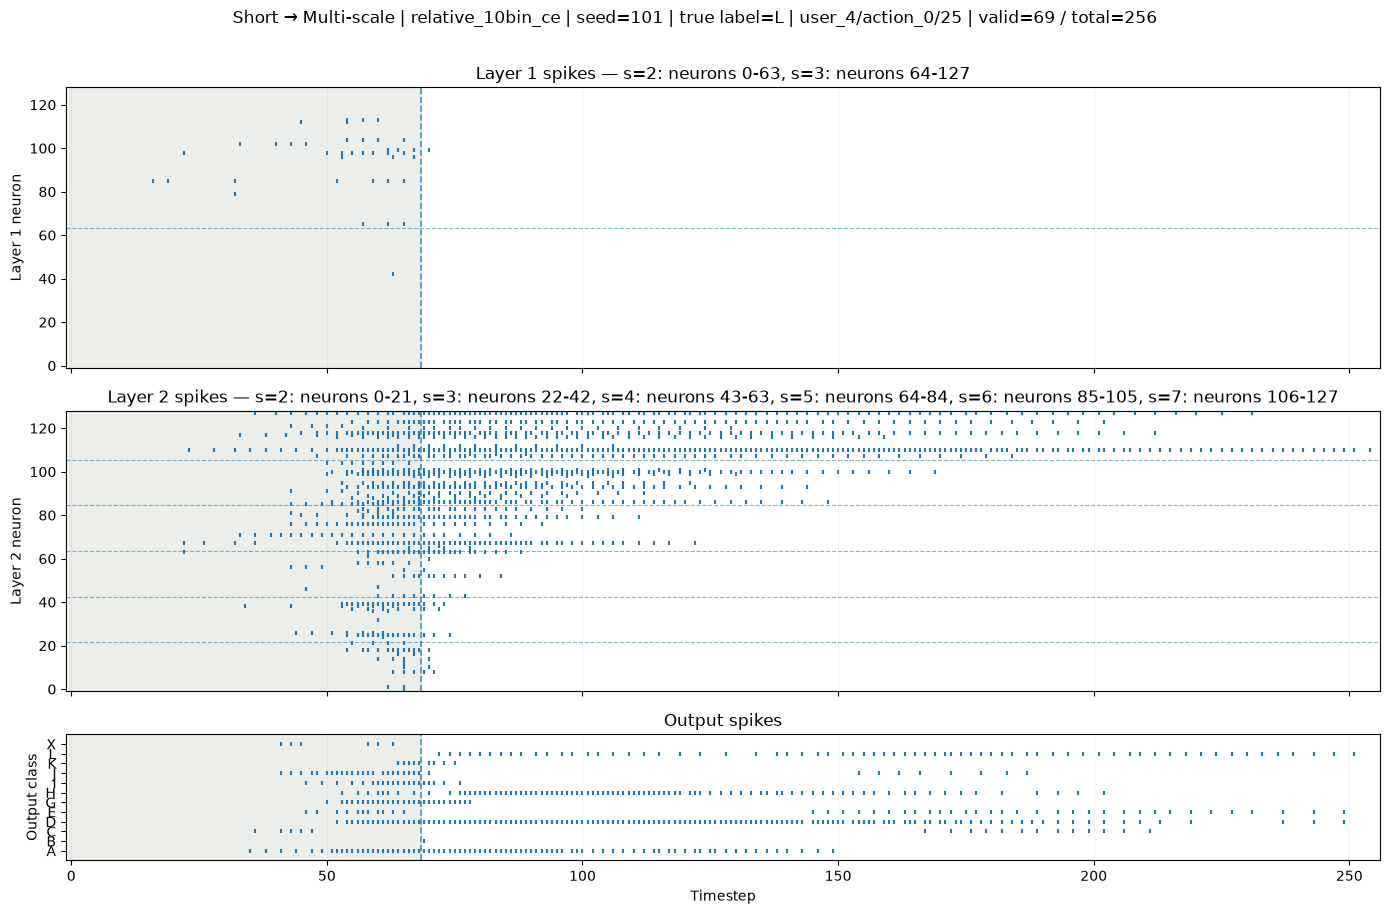

Multi-scale → Short | timestep_ce: raster uses seed=11, best val BA=0.3660


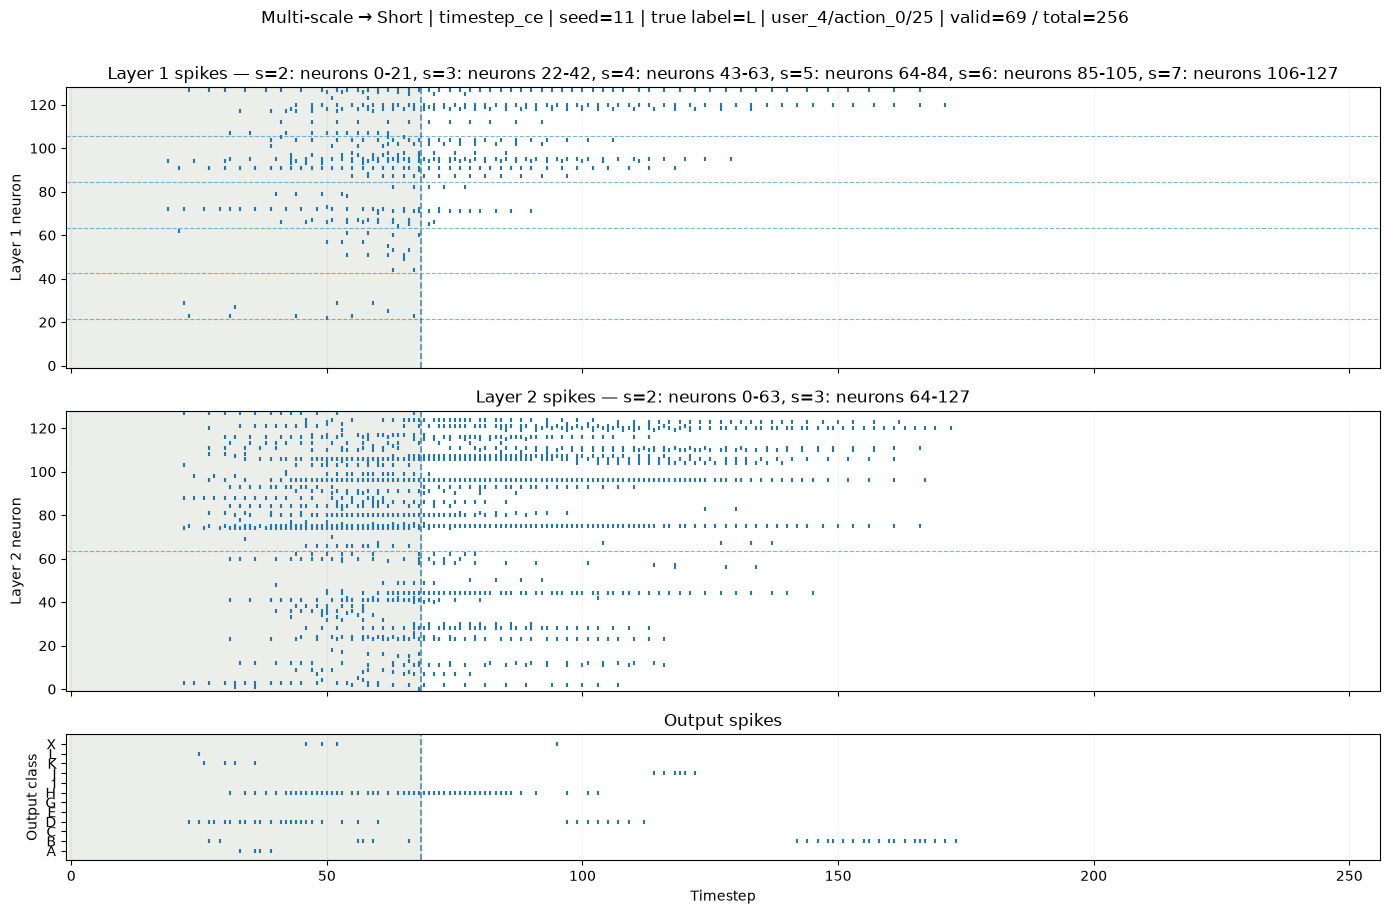

Multi-scale → Short | relative_10bin_ce: raster uses seed=101, best val BA=0.5694


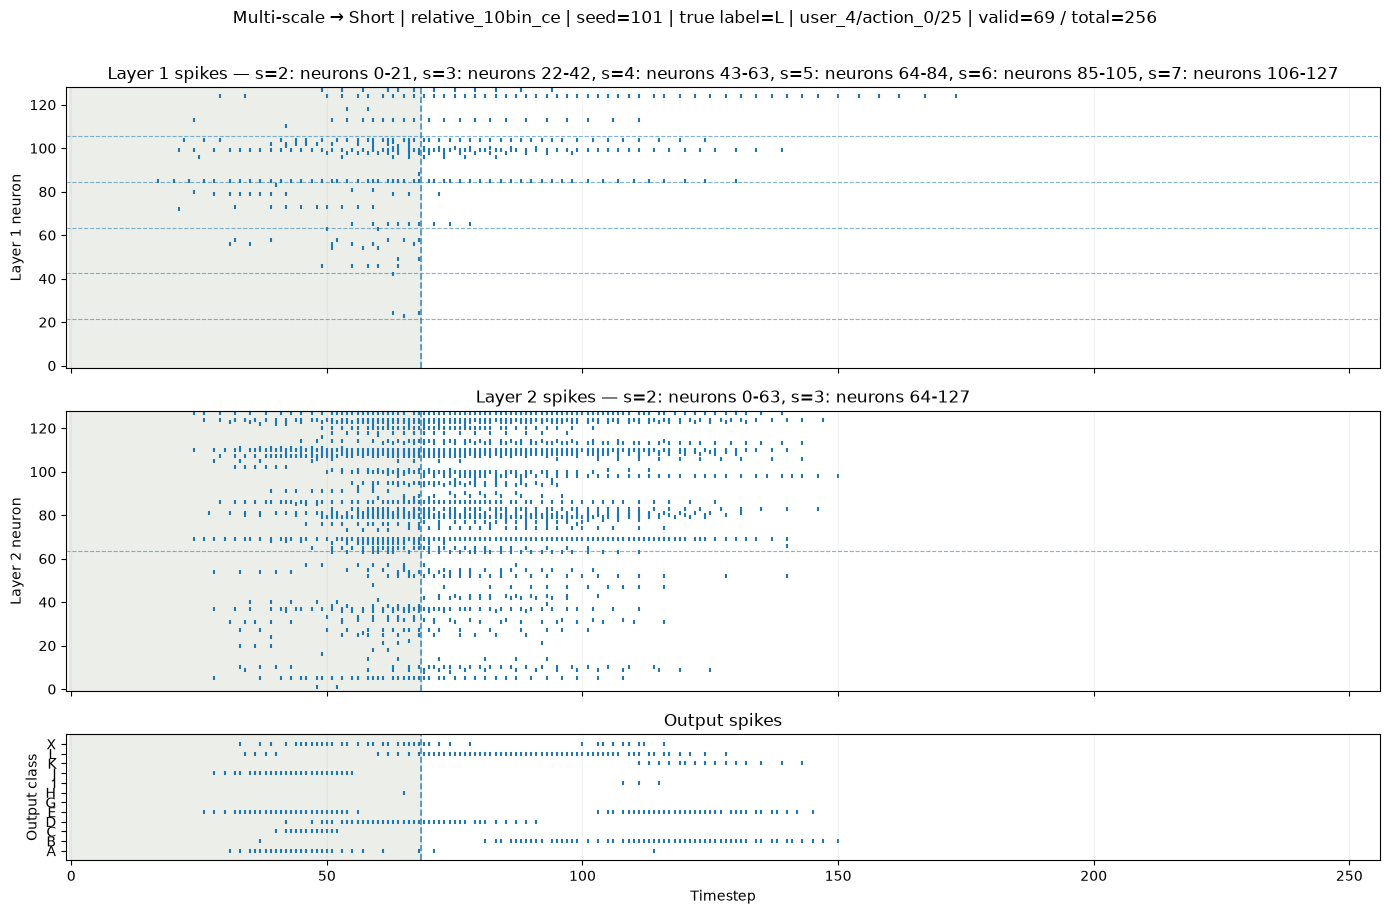

In [164]:
def load_best_checkpoint_model(
    configuration: LayerwiseTauConfiguration,
    objective: str,
    master_seed: int,
):
    loaded = load_completed_run(
        configuration,
        objective,
        master_seed,
    )
    if loaded is None:
        raise FileNotFoundError(
            checkpoint_path(
                configuration,
                objective,
                master_seed,
            )
        )
    model = loaded["model"]
    model.eval()
    return model


def get_raster_sample(
    split_name="val",
    index=0,
):
    subset = FIXED_SPLIT_MANIFEST[
        FIXED_SPLIT_MANIFEST.split == split_name
    ]
    dataset = EventSNNDataset(data, subset)
    return dataset[index]


@torch.no_grad()
def run_single_sample(
    model,
    sample,
):
    x = sample["x"][None, ...].to(DEVICE)
    mask = sample["valid_mask"][None, ...].to(DEVICE)

    out = model(x, mask)

    valid_length = int(sample["valid_length"].item())
    total_length = int(sample["x"].shape[0])

    return {
        # Keep the full padded segment for the raster; valid region is highlighted.
        "hidden_1": (
            out["hidden_spikes"][0][0]
            .detach()
            .cpu()
            .numpy()
        ),
        "hidden_2": (
            out["hidden_spikes"][1][0]
            .detach()
            .cpu()
            .numpy()
        ),
        "output": (
            out["output_spikes"][0]
            .detach()
            .cpu()
            .numpy()
        ),
        "valid_length": valid_length,
        "total_length": total_length,
    }


def add_group_boundaries(
    ax,
    groups,
):
    for _, _, stop in groups[:-1]:
        ax.axhline(
            stop - 0.5,
            linestyle="--",
            linewidth=0.8,
            alpha=0.55,
        )


def raster_points(ax, spikes):
    time_idx, neuron_idx = np.nonzero(spikes > 0)

    ax.scatter(
        time_idx,
        neuron_idx,
        s=10,
        marker="|",
    )


def highlight_valid_region(
    ax,
    valid_length,
    total_length,
    color="#b8c4b1",
    alpha=0.28,
):
    ax.axvspan(
        -0.5,
        valid_length - 0.5,
        color=color,
        alpha=alpha,
        zorder=0,
    )
    ax.axvline(
        valid_length - 0.5,
        linestyle="--",
        linewidth=1.2,
        alpha=0.8,
    )


def group_description(groups):
    return ", ".join(
        f"s={shift}: neurons {start}-{stop - 1}"
        for shift, start, stop in groups
    )


def plot_spike_raster(
    model,
    sample,
    *,
    configuration: LayerwiseTauConfiguration,
    objective: str,
    master_seed: int,
):
    activity = run_single_sample(model, sample)

    valid_length = activity["valid_length"]
    total_length = activity["total_length"]

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(14, 9),
        sharex=True,
        gridspec_kw={
            "height_ratios": [1, 1, 0.45]
        },
    )

    for axis, key, groups, layer_name in (
        (axes[0], "hidden_1", model.layer_group_slices[0], "Layer 1"),
        (axes[1], "hidden_2", model.layer_group_slices[1], "Layer 2"),
    ):
        highlight_valid_region(
            axis,
            valid_length,
            total_length,
        )
        raster_points(
            axis,
            activity[key],
        )
        add_group_boundaries(
            axis,
            groups,
        )
        axis.set_ylim(-1, model.width)
        axis.set_ylabel(f"{layer_name} neuron")
        axis.set_title(
            f"{layer_name} spikes — {group_description(groups)}"
        )

    highlight_valid_region(
        axes[2],
        valid_length,
        total_length,
    )
    raster_points(
        axes[2],
        activity["output"],
    )
    axes[2].set_ylim(-1, NUM_CLASSES)
    axes[2].set_yticks(range(NUM_CLASSES))
    axes[2].set_yticklabels(
        [
            IDX_TO_CLASS[i]
            for i in range(NUM_CLASSES)
        ]
    )
    axes[2].set_ylabel("Output class")
    axes[2].set_xlabel("Timestep")
    axes[2].set_title("Output spikes")

    for ax in axes:
        ax.set_xlim(-1, total_length)
        ax.grid(axis="x", alpha=0.15)

    label_idx = int(sample["label"].item())
    sample_id = sample["sample_id"]

    fig.suptitle(
        f"{configuration.label} | {objective} | seed={master_seed} | "
        f"true label={IDX_TO_CLASS[label_idx]} | "
        f"{sample_id} | "
        f"valid={valid_length} / total={total_length}",
        y=1.01,
    )

    plt.tight_layout()
    plt.show()


RASTER_SPLIT = "val"
RASTER_SAMPLE_INDEX = 0

raster_sample = get_raster_sample(
    RASTER_SPLIT,
    RASTER_SAMPLE_INDEX,
)

for configuration in CONFIGURATIONS:
    for objective in OBJECTIVES:
        best_row = (
            results_df[
                (results_df.configuration == configuration.configuration_id)
                & (results_df.objective == objective)
            ]
            .sort_values(
                [
                    "best_val_ba",
                    "val_loss_at_best_val_ba",
                ],
                ascending=[False, True],
            )
            .iloc[0]
        )

        best_seed = int(best_row["seed"])

        print(
            f"{configuration.label} | {objective}: "
            f"raster uses seed={best_seed}, "
            f"best val BA={best_row['best_val_ba']:.4f}"
        )

        raster_model = load_best_checkpoint_model(
            configuration,
            objective,
            best_seed,
        )

        plot_spike_raster(
            raster_model,
            raster_sample,
            configuration=configuration,
            objective=objective,
            master_seed=best_seed,
        )

        del raster_model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

## 16. Per-$\tau_{\mathrm{syn}}$ firing-rate summary

This checks whether all nominal temporal scales are actually active. A slow group can carry
temporal state while firing less frequently than a fast group, so interpret these rates together
with the raster plots and classification results.

,configuration,configuration_label,objective,layer,shift,tau_syn_ms,mean,std
0,single_scale_2,Single-scale 2,timestep_ce,L1,2,54.313430,0.011207,0.001828
1,single_scale_2,Single-scale 2,timestep_ce,L2,2,54.313430,0.093744,0.016992
2,single_scale_2,Single-scale 2,relative_10bin_ce,L1,2,54.313430,0.005782,0.000679
3,single_scale_2,Single-scale 2,relative_10bin_ce,L2,2,54.313430,0.039460,0.009522
4,single_scale_3,Single-scale 3,timestep_ce,L1,3,117.013683,0.024816,0.002166
5,single_scale_3,Single-scale 3,timestep_ce,L2,3,117.013683,0.183057,0.004242
6,single_scale_3,Single-scale 3,relative_10bin_ce,L1,3,117.013683,0.014350,0.002100
7,single_scale_3,Single-scale 3,relative_10bin_ce,L2,3,117.013683,0.102215,0.012494
8,short_to_multi_scale,Short → Multi-scale,timestep_ce,L1,2,54.313430,0.001662,0.000747
9,short_to_multi_scale,Short → Multi-scale,timestep_ce,L1,3,117.013683,0.015762,0.002792


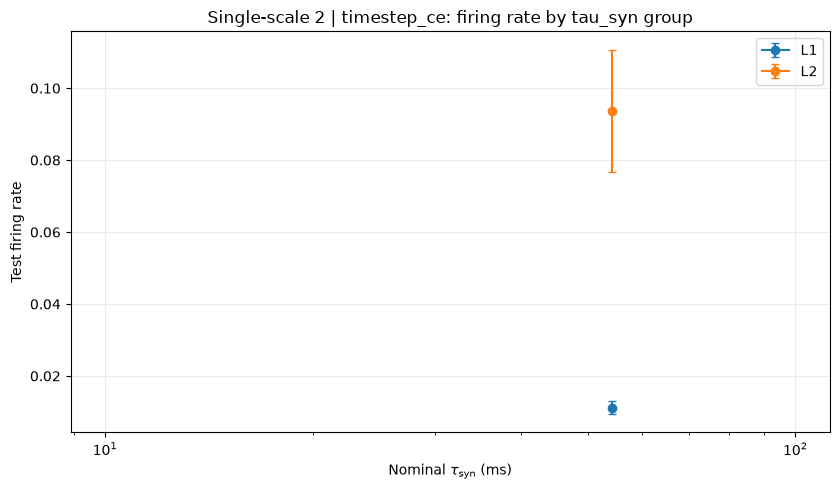

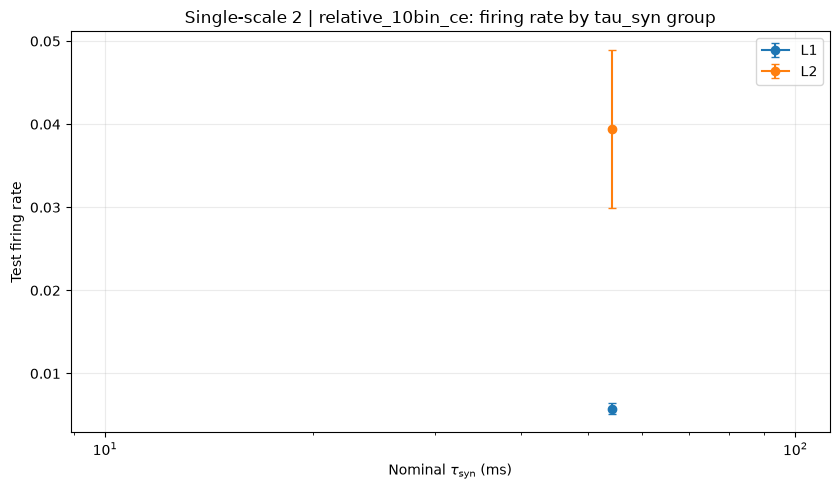

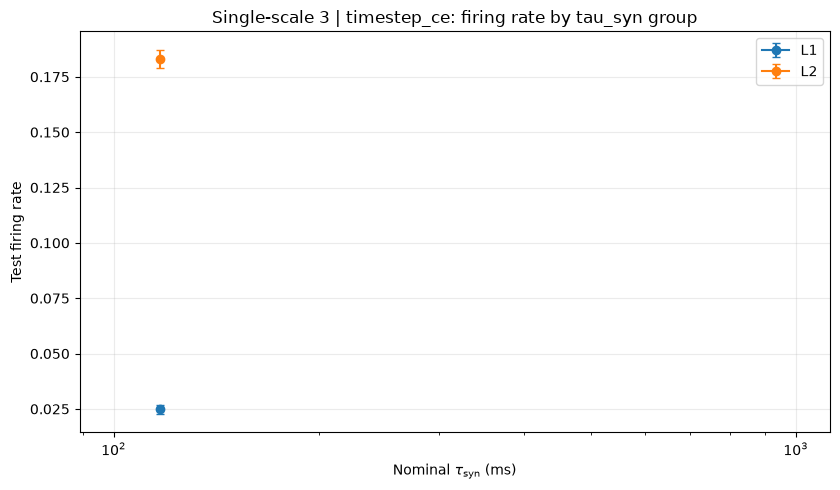

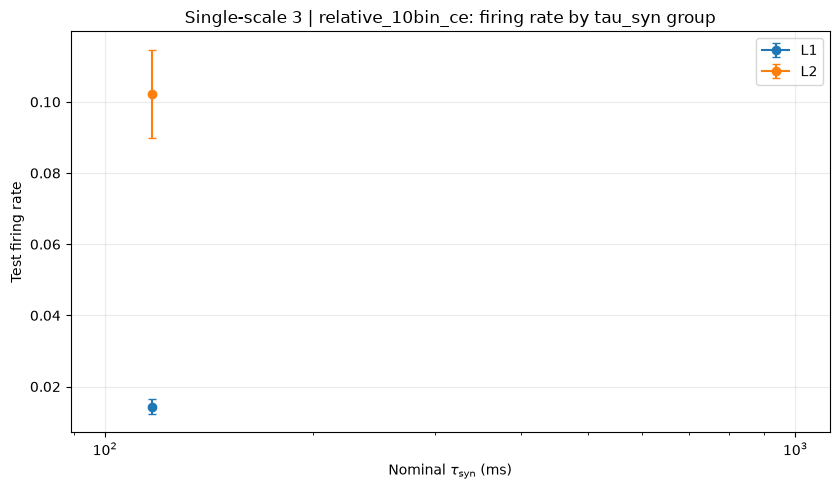

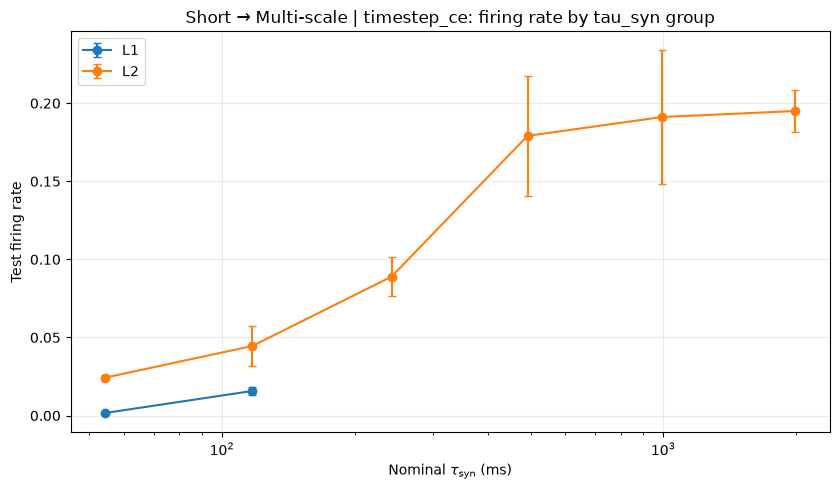

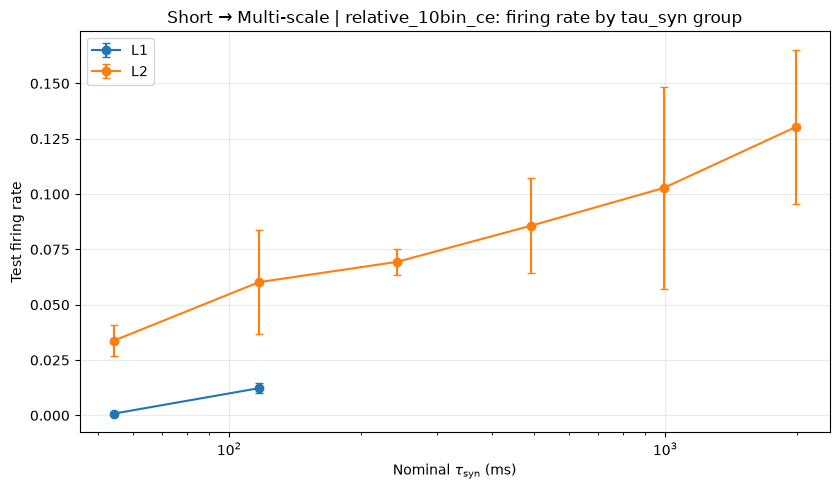

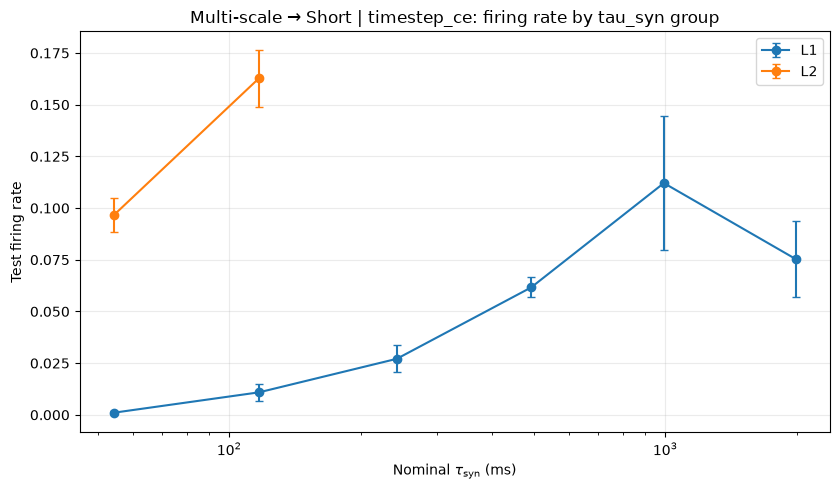

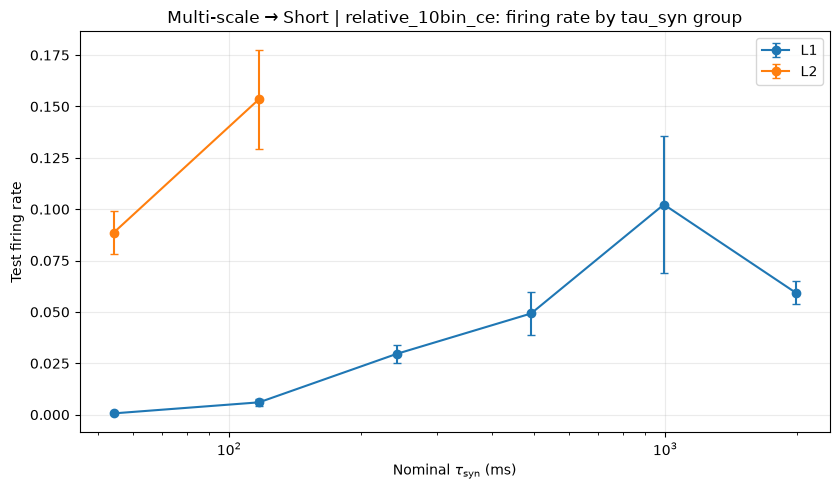

In [165]:
group_metric_rows = []

for _, row in results_df.iterrows():
    configuration = CONFIGURATION_BY_ID[row["configuration"]]

    for layer_idx, shifts in (
        (1, configuration.layer1_shifts),
        (2, configuration.layer2_shifts),
    ):
        for shift in shifts:
            metric = (
                f"test_hidden_{layer_idx}_"
                f"shift_{shift}_firing_rate"
            )

            group_metric_rows.append(
                {
                    "configuration": configuration.configuration_id,
                    "configuration_label": configuration.label,
                    "objective": row["objective"],
                    "seed": int(row["seed"]),
                    "layer": f"L{layer_idx}",
                    "shift": int(shift),
                    "tau_syn_ms": alpha_to_tau_ms(
                        shift_to_alpha(shift),
                        SAMPLING_RATE_HZ,
                    ),
                    "test_firing_rate": row[metric],
                }
            )

group_fr_df = pd.DataFrame(group_metric_rows)

group_fr_summary = (
    group_fr_df
    .groupby(
        [
            "configuration",
            "configuration_label",
            "objective",
            "layer",
            "shift",
            "tau_syn_ms",
        ],
        sort=False,
    )["test_firing_rate"]
    .agg(["mean", "std"])
    .reset_index()
)

display(group_fr_summary)

group_fr_summary.to_csv(
    RESULTS_DIR / "experiment_3_0_tau_group_firing_rates.csv",
    index=False,
)

for configuration in CONFIGURATIONS:
    for objective in OBJECTIVES:
        sdf = group_fr_summary[
            (group_fr_summary.configuration == configuration.configuration_id)
            & (group_fr_summary.objective == objective)
        ]

        fig, ax = plt.subplots(figsize=(8.5, 5))

        for layer_name in ("L1", "L2"):
            ldf = sdf[
                sdf.layer == layer_name
            ].sort_values("tau_syn_ms")

            ax.errorbar(
                ldf["tau_syn_ms"],
                ldf["mean"],
                yerr=ldf["std"],
                marker="o",
                capsize=3,
                label=layer_name,
            )

        ax.set_xscale("log")
        ax.set_xlabel(r"Nominal $\tau_{\mathrm{syn}}$ (ms)")
        ax.set_ylabel("Test firing rate")
        ax.set_title(
            f"{configuration.label} | {objective}: "
            "firing rate by tau_syn group"
        )
        ax.grid(alpha=0.25)
        ax.legend()

        plt.tight_layout()
        plt.show()

In [166]:
# =============================================================================
# Save Experiment 3.0 results + architecture metadata
# =============================================================================

EXPERIMENT_TITLE = (
    "Experiment 3.0 - Layer-wise Multi-Tau Synaptic SNN Comparison"
)

SAVE_DIR = RESULTS_DIR
SAVE_DIR.mkdir(parents=True, exist_ok=True)


# -----------------------------------------------------------------------------
# Architecture / tau_syn metadata
# -----------------------------------------------------------------------------

architecture_metadata = {
    "title": EXPERIMENT_TITLE,
    "experiment_id": EXPERIMENT_ID,
    "input_channels": int(INPUT_CHANNELS),
    "num_classes": int(NUM_CLASSES),
    "hidden_layers": 2,
    "neurons_per_layer": [
        int(HIDDEN_WIDTH),
        int(HIDDEN_WIDTH),
    ],
    "configurations": [
        configuration_metadata(configuration)
        for configuration in CONFIGURATIONS
    ],
    "tau_mem_ms": float(TAU_MEM_MS),
    "tau_syn_output_ms": float(TAU_SYN_OUT_MS),
    "threshold": float(THRESHOLD),
    "sampling_rate_hz": float(SAMPLING_RATE_HZ),
    "objectives": list(OBJECTIVES),
    "training_seeds": list(SEEDS),
    "split_seed": int(SPLIT_SEED),
    "expected_training_runs": int(EXPECTED_TRAINING_RUNS),
    "num_epochs": int(NUM_EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "learning_rate": float(LEARNING_RATE),
}


# -----------------------------------------------------------------------------
# Add architecture description directly to per-run result table
# -----------------------------------------------------------------------------

results_to_save = results_df.copy()

results_to_save.insert(
    0,
    "title",
    EXPERIMENT_TITLE,
)

results_to_save["neurons_per_layer"] = (
    f"{HIDDEN_WIDTH}/{HIDDEN_WIDTH}"
)

results_to_save["L1_shift_syn"] = results_to_save[
    "configuration"
].map(
    lambda configuration_id: str(
        list(
            CONFIGURATION_BY_ID[
                configuration_id
            ].layer1_shifts
        )
    )
)

results_to_save["L1_tau_syn_ms"] = results_to_save[
    "configuration"
].map(
    lambda configuration_id: str(
        [
            round(
                alpha_to_tau_ms(
                    shift_to_alpha(shift),
                    SAMPLING_RATE_HZ,
                ),
                6,
            )
            for shift in CONFIGURATION_BY_ID[
                configuration_id
            ].layer1_shifts
        ]
    )
)

results_to_save["L1_neurons_per_tau"] = results_to_save[
    "configuration"
].map(
    lambda configuration_id: str(
        list(
            CONFIGURATION_BY_ID[
                configuration_id
            ].layer1_counts
        )
    )
)

results_to_save["L2_shift_syn"] = results_to_save[
    "configuration"
].map(
    lambda configuration_id: str(
        list(
            CONFIGURATION_BY_ID[
                configuration_id
            ].layer2_shifts
        )
    )
)

results_to_save["L2_tau_syn_ms"] = results_to_save[
    "configuration"
].map(
    lambda configuration_id: str(
        [
            round(
                alpha_to_tau_ms(
                    shift_to_alpha(shift),
                    SAMPLING_RATE_HZ,
                ),
                6,
            )
            for shift in CONFIGURATION_BY_ID[
                configuration_id
            ].layer2_shifts
        ]
    )
)

results_to_save["L2_neurons_per_tau"] = results_to_save[
    "configuration"
].map(
    lambda configuration_id: str(
        list(
            CONFIGURATION_BY_ID[
                configuration_id
            ].layer2_counts
        )
    )
)


# -----------------------------------------------------------------------------
# Save
# -----------------------------------------------------------------------------

results_save_path = (
    SAVE_DIR
    / "experiment_3_0_results_with_architecture.csv"
)

summary_save_path = (
    SAVE_DIR
    / "experiment_3_0_configuration_objective_summary.csv"
)

all_histories_save_path = (
    SAVE_DIR
    / "experiment_3_0_all_histories.csv"
)

metadata_save_path = (
    SAVE_DIR
    / "experiment_3_0_architecture.json"
)

results_to_save.to_csv(
    results_save_path,
    index=False,
)

summary_df.to_csv(
    summary_save_path,
    index=False,
)

histories_df.to_csv(
    all_histories_save_path,
    index=False,
)

with open(
    metadata_save_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        architecture_metadata,
        f,
        indent=2,
        sort_keys=True,
    )


# -----------------------------------------------------------------------------
# Print saved configuration
# -----------------------------------------------------------------------------

print("=" * 100)
print(EXPERIMENT_TITLE)
print("=" * 100)

print(f"Hidden width: {HIDDEN_WIDTH} / {HIDDEN_WIDTH}")
print("Configurations:", len(CONFIGURATIONS))

for configuration in CONFIGURATIONS:
    print(
        " ",
        configuration.label,
        "| L1:",
        list(zip(configuration.layer1_shifts, configuration.layer1_counts)),
        "| L2:",
        list(zip(configuration.layer2_shifts, configuration.layer2_counts)),
    )

print("Objectives:", OBJECTIVES)
print("Training seeds:", SEEDS)
print("Training runs:", EXPECTED_TRAINING_RUNS)
print("Split seed:", SPLIT_SEED)

print("\nSaved:")
print(" ", results_save_path)
print(" ", summary_save_path)
print(" ", all_histories_save_path)
print(" ", metadata_save_path)

# =============================================================================
# Figure saving configuration
# =============================================================================

FIGURE_DIR = RESULTS_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PNG = True
SAVE_PDF = True
FIGURE_DPI = 300


def save_figure(fig, filename_stem):
    """
    Save a matplotlib figure to the experiment figures directory.

    Example:
        save_figure(fig, "val_ba_vs_epoch")
    """

    filename_stem = str(filename_stem).replace(" ", "_")

    saved_paths = []

    if SAVE_PNG:
        path = FIGURE_DIR / f"{filename_stem}.png"
        fig.savefig(
            path,
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )
        saved_paths.append(path)

    if SAVE_PDF:
        path = FIGURE_DIR / f"{filename_stem}.pdf"
        fig.savefig(
            path,
            bbox_inches="tight",
        )
        saved_paths.append(path)

    for path in saved_paths:
        print("Saved figure:", path)

    return saved_paths


print("Figure directory:", FIGURE_DIR)

Experiment 3.0 - Layer-wise Multi-Tau Synaptic SNN Comparison
Hidden width: 128 / 128
Configurations: 4
  Single-scale 2 | L1: [(2, 128)] | L2: [(2, 128)]
  Single-scale 3 | L1: [(3, 128)] | L2: [(3, 128)]
  Short → Multi-scale | L1: [(2, 64), (3, 64)] | L2: [(2, 22), (3, 21), (4, 21), (5, 21), (6, 21), (7, 22)]
  Multi-scale → Short | L1: [(2, 22), (3, 21), (4, 21), (5, 21), (6, 21), (7, 22)] | L2: [(2, 64), (3, 64)]
Objectives: ('timestep_ce', 'relative_10bin_ce')
Training seeds: (11, 23, 101)
Training runs: 24
Split seed: 12345

Saved:
  /home/ted/project/writingring-viz/notebooks/artifacts/experiment_3_0_phase_c_layerwise_multitau_comparison/experiment_3_0_results_with_architecture.csv
  /home/ted/project/writingring-viz/notebooks/artifacts/experiment_3_0_phase_c_layerwise_multitau_comparison/experiment_3_0_configuration_objective_summary.csv
  /home/ted/project/writingring-viz/notebooks/artifacts/experiment_3_0_phase_c_layerwise_multitau_comparison/experiment_3_0_all_histories.csv

## Interpretation checklist

The primary comparison is the paired five-seed difference between `timestep_ce` and
`relative_10bin_ce` under the same multi-$\tau_{\mathrm{syn}}$ backbone.

Check:

- Does validation BA rise consistently above chance for both objectives?
- Which objective has higher mean validation/test BA and lower seed variance?
- Do L1 and L2 maintain healthy firing rates without zero-input firing?
- Are the L2 \(s=6\) and \(s=7\) groups active?
- Do the raster plots show different temporal activity patterns across ordered
  $\tau_{\mathrm{syn}}$ groups?
- Does `timestep_ce` produce more sustained timestep-wise class evidence?
- Does `relative_10bin_ce` benefit more from gesture-phase-specific activity?

A later matched control should compare this 128→128 multi-$\tau$ architecture with a
128→128 single-$\tau$ architecture so any performance change can be attributed to temporal
heterogeneity rather than width.